# Clasificación de imágenes con Redes Neuronales Convolucionales (CNN)

## 1. ¿Qué es una CNN y por qué se usa en imágenes?

Una Red Neuronal Convolucional (CNN) es un tipo de red neuronal diseñada especialmente para trabajar con imágenes.

Las CNN utilizan filtros o kernels que recorren la imagen para detectar características visuales. En las primeras capas pueden aprender características simples como bordes, colores y texturas, mientras que las capas posteriores combinan estas características para reconocer patrones más complejos.

En este trabajo se utilizará el dataset DermaMNIST para realizar una clasificación binaria entre:

- Nevo melanocítico (clase 0)
- Melanoma (clase 1)

Primero se entrenará una CNN desde cero y posteriormente se realizarán experimentos modificando su arquitectura y parámetros de entrenamiento.

## 2. Preparación del entorno

In [1]:
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "medmnist",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm"
]

for p in packages:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        p
    ])

print("Instalación terminada")

Instalación terminada


In [2]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA disponible: True
GPU: Tesla T4


## 3. Cargar el dataset médico (DermaMNIST)

In [3]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm import tqdm

import medmnist
from medmnist import INFO

data_flag = "dermamnist"

info = INFO[data_flag]

DataClass = getattr(medmnist, info["python_class"])

info

{'python_class': 'DermaMNIST',
 'description': 'The DermaMNIST is based on the HAM10000, a large collection of multi-source dermatoscopic images of common pigmented skin lesions. The dataset consists of 10,015 dermatoscopic images categorized as 7 different diseases, formulized as a multi-class classification task. We split the images into training, validation and test set with a ratio of 7:1:2. The source images of 3×600×450 are resized into 3×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/dermamnist.npz?download=1',
 'MD5': '0744692d530f8e62ec473284d019b0c7',
 'url_64': 'https://zenodo.org/records/10519652/files/dermamnist_64.npz?download=1',
 'MD5_64': 'b70a2f5635c6199aeaa28c31d7202e1f',
 'url_128': 'https://zenodo.org/records/10519652/files/dermamnist_128.npz?download=1',
 'MD5_128': '2defd784463fa5243564e855ed717de1',
 'url_224': 'https://zenodo.org/records/10519652/files/dermamnist_224.npz?download=1',
 'MD5_224': '8974907d8e169bef5f5b96bc506ae45d',
 'task': 'multi-c

In [4]:
transform_basic = T.Compose([
    T.ToTensor()
])

train_dataset_full = DataClass(
    split="train",
    transform=transform_basic,
    download=True
)

val_dataset_full = DataClass(
    split="val",
    transform=transform_basic,
    download=True
)

test_dataset_full = DataClass(
    split="test",
    transform=transform_basic,
    download=True
)

len(train_dataset_full), len(val_dataset_full), len(test_dataset_full)

100%|██████████| 19.7M/19.7M [00:03<00:00, 5.44MB/s]


(7007, 1003, 2005)

In [5]:
from torch.utils.data import Dataset

class BinaryDermaDataset(Dataset):

    def __init__(self, dataset):

        self.dataset = dataset

        labels = dataset.labels.squeeze()

        # DermaMNIST:
        # 4 = melanoma
        # 5 = melanocytic nevus

        self.indices = np.where(
            (labels == 4) | (labels == 5)
        )[0]

        selected_labels = labels[self.indices]

        # Nueva codificación:
        # 0 = Nevo melanocítico
        # 1 = Melanoma

        self.labels = np.where(
            selected_labels == 4,
            1,
            0
        ).astype(np.int64)

    def __len__(self):

        return len(self.indices)

    def __getitem__(self, idx):

        original_idx = self.indices[idx]

        image, _ = self.dataset[original_idx]

        label = self.labels[idx]

        return image, torch.tensor(
            [label],
            dtype=torch.long
        )


train_dataset = BinaryDermaDataset(train_dataset_full)
val_dataset = BinaryDermaDataset(val_dataset_full)
test_dataset = BinaryDermaDataset(test_dataset_full)

len(train_dataset), len(val_dataset), len(test_dataset)

(5472, 782, 1564)

In [6]:
print(
    "Train:",
    np.bincount(train_dataset.labels)
)

print(
    "Validation:",
    np.bincount(val_dataset.labels)
)

print(
    "Test:",
    np.bincount(test_dataset.labels)
)

Train: [4693  779]
Validation: [671 111]
Test: [1341  223]


###3.1 Visualizar ejemplos

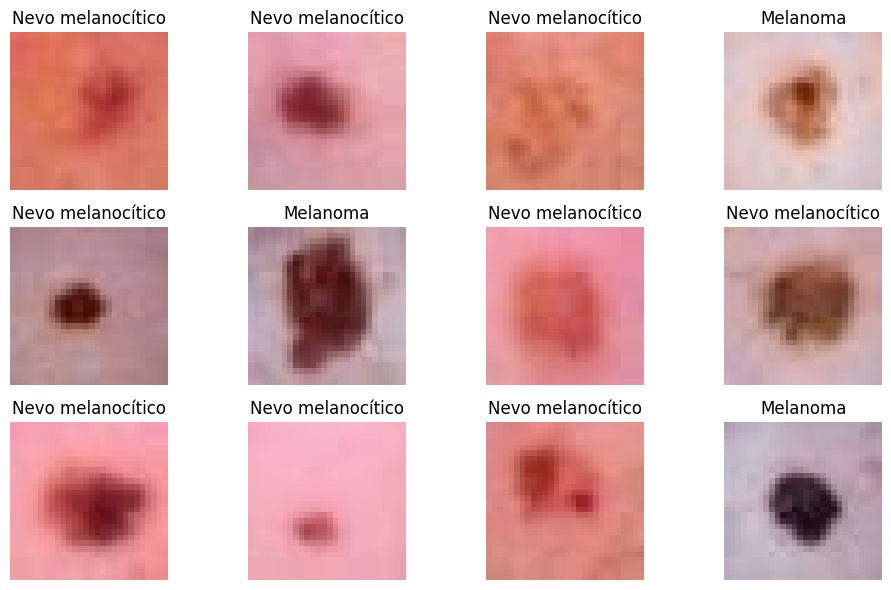

In [7]:
class_names = [
    "Nevo melanocítico",
    "Melanoma"
]

def show_batch(dataset, n=12):

    plt.figure(figsize=(10, 6))

    for i in range(n):

        x, y = dataset[i]

        plt.subplot(3, 4, i + 1)

        img = x.permute(1, 2, 0)

        plt.imshow(img)

        plt.title(
            class_names[int(y.item())]
        )

        plt.axis("off")

    plt.tight_layout()

    plt.show()


show_batch(
    train_dataset,
    n=12
)

## 4. Preparar DataLoaders y device

In [8]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

device

device(type='cuda')

In [9]:
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape

(torch.Size([128, 3, 28, 28]), torch.Size([128, 1]))

## 5. CNN entrenada desde cero

In [10]:
import torch.nn as nn
import torch.nn.functional as F

num_classes = 2

class SimpleCNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                3,
                16,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                16,
                32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d(
                (1, 1)
            )
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                64,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x


model_scratch = SimpleCNN(
    num_classes=num_classes
).to(device)

model_scratch

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=2, bias=True)
  )
)

### 5.1 Funciones de entrenamiento y evaluación

In [11]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

def logits_to_probs(logits):

    if logits.shape[1] == 1:

        return torch.sigmoid(
            logits
        ).squeeze(1)

    return torch.softmax(
        logits,
        dim=1
    )[:, 1]


@torch.no_grad()
def evaluate(model, loader, criterion):

    model.eval()

    all_labels = []
    all_probs = []
    all_preds = []

    losses = []

    for x, y in loader:

        x = x.to(device)

        y = (
            y.to(device)
            .long()
            .squeeze(1)
        )

        logits = model(x)

        # Pérdida de validación
        loss = criterion(
            logits,
            y
        )

        losses.append(
            loss.item()
        )

        probs = logits_to_probs(
            logits
        )

        preds = (
            probs >= 0.5
        ).long()

        all_labels.append(
            y.cpu().numpy()
        )

        all_probs.append(
            probs.cpu().numpy()
        )

        all_preds.append(
            preds.cpu().numpy()
        )

    y_true = np.concatenate(
        all_labels
    )

    y_prob = np.concatenate(
        all_probs
    )

    y_pred = np.concatenate(
        all_preds
    )

    val_loss = float(
        np.mean(losses)
    )

    acc = accuracy_score(
        y_true,
        y_pred
    )

    auc = roc_auc_score(
        y_true,
        y_prob
    )

    return (
        val_loss,
        acc,
        auc,
        y_true,
        y_pred,
        y_prob
    )


def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion
):

    model.train()

    losses = []

    for x, y in loader:

        x = x.to(device)

        y = (
            y.to(device)
            .long()
            .squeeze(1)
        )

        optimizer.zero_grad()

        logits = model(x)

        loss = criterion(
            logits,
            y
        )

        loss.backward()

        optimizer.step()

        losses.append(
            loss.item()
        )

    return float(
        np.mean(losses)
    )

### 5.2 Entrenar CNN original

In [12]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_scratch.parameters(),
    lr=1e-3
)

epochs = 40

history_scratch = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(
    1,
    epochs + 1
):

    train_loss = train_one_epoch(
        model_scratch,
        train_loader,
        optimizer,
        criterion
    )

    (
        val_loss,
        val_acc,
        val_auc,
        _,
        _,
        _
    ) = evaluate(
        model_scratch,
        val_loader,
        criterion
    )

    history_scratch[
        "train_loss"
    ].append(train_loss)

    history_scratch[
        "val_loss"
    ].append(val_loss)

    history_scratch[
        "val_acc"
    ].append(val_acc)

    history_scratch[
        "val_auc"
    ].append(val_auc)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

Epoch 01 | train_loss=0.4380 | val_loss=0.3958 | val_acc=0.8581 | val_auc=0.6598
Epoch 02 | train_loss=0.3901 | val_loss=0.3785 | val_acc=0.8581 | val_auc=0.7368
Epoch 03 | train_loss=0.3747 | val_loss=0.3532 | val_acc=0.8581 | val_auc=0.7240
Epoch 04 | train_loss=0.3592 | val_loss=0.3431 | val_acc=0.8581 | val_auc=0.7264
Epoch 05 | train_loss=0.3472 | val_loss=0.3327 | val_acc=0.8581 | val_auc=0.7385
Epoch 06 | train_loss=0.3376 | val_loss=0.3313 | val_acc=0.8581 | val_auc=0.7662
Epoch 07 | train_loss=0.3344 | val_loss=0.3232 | val_acc=0.8581 | val_auc=0.8085
Epoch 08 | train_loss=0.3257 | val_loss=0.3143 | val_acc=0.8581 | val_auc=0.8226
Epoch 09 | train_loss=0.3209 | val_loss=0.3243 | val_acc=0.8581 | val_auc=0.8361
Epoch 10 | train_loss=0.3304 | val_loss=0.3227 | val_acc=0.8581 | val_auc=0.8231
Epoch 11 | train_loss=0.3218 | val_loss=0.3058 | val_acc=0.8581 | val_auc=0.8442
Epoch 12 | train_loss=0.3231 | val_loss=0.3096 | val_acc=0.8619 | val_auc=0.8326
Epoch 13 | train_loss=0.3113

### 5.3 Curvas de entrenamiento

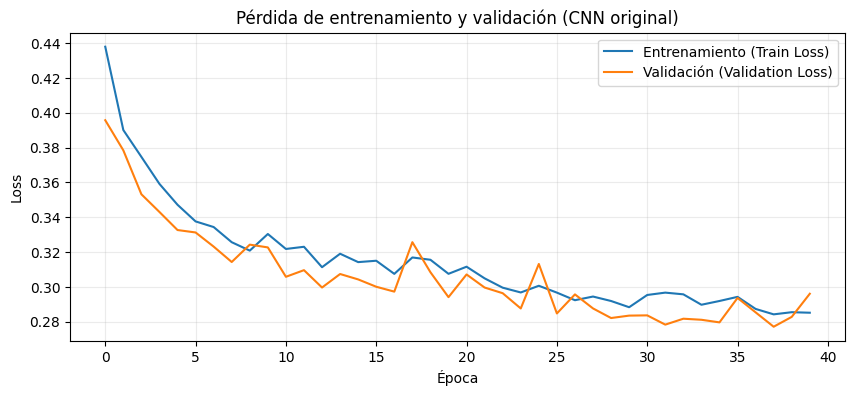

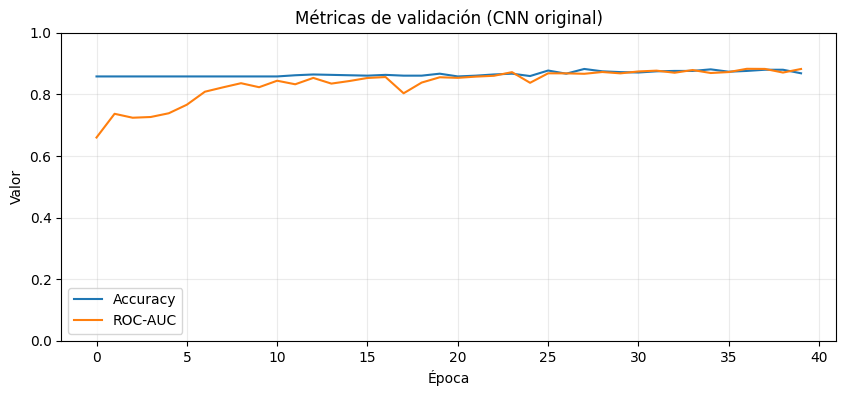

In [13]:
plt.figure(figsize=(10, 4))

plt.plot(
    history_scratch["train_loss"],
    label="Entrenamiento (Train Loss)"
)

plt.plot(
    history_scratch["val_loss"],
    label="Validación (Validation Loss)"
)

plt.title(
    "Pérdida de entrenamiento y validación (CNN original)"
)

plt.xlabel("Época")

plt.ylabel("Loss")

plt.legend()

plt.grid(alpha=0.25)

plt.show()

plt.figure(figsize=(10, 4))

plt.plot(
    history_scratch["val_acc"],
    label="Accuracy"
)

plt.plot(
    history_scratch["val_auc"],
    label="ROC-AUC"
)

plt.title(
    "Métricas de validación (CNN original)"
)

plt.xlabel("Época")

plt.ylabel("Valor")

plt.ylim(0, 1)

plt.legend()

plt.grid(alpha=0.25)

plt.show()

### 5.4 Experimento de arquitectura:

#### 5.4.1 Cantidad de filtros

Se evaluó el efecto de modificar la cantidad de filtros de la última capa convolucional, manteniendo constantes los demás parámetros de entrenamiento.

Se probaron las configuraciones 16-32-16, 16-32-32, 16-32-64 y 16-32-128.

Los resultados muestran una mejora progresiva al incrementar la capacidad de la red hasta 64 filtros. Aunque la configuración 16-32-128 obtuvo una pérdida de validación ligeramente menor, la diferencia respecto a 16-32-64 fue pequeña y no estuvo acompañada de una mejora en Accuracy y ROC-AUC.

Por ello, se seleccionó la configuración 16-32-64 para los siguientes experimentos. Los experimentos se realizaron en la etapa 5.2

#### 5.4.2 Experimento con Dropout

In [14]:
import torch.nn as nn

class SimpleCNNDropout(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Dropout(0.20),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model_dropout = SimpleCNNDropout(
    num_classes=num_classes
).to(device)

model_dropout

SimpleCNNDropout(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=2, bias=True)
  )
)

In [15]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_dropout.parameters(),
    lr=0.001
)

epochs = 40

history_dropout = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(1, epochs + 1):

    train_loss = train_one_epoch(
        model_dropout,
        train_loader,
        optimizer,
        criterion
    )

    (
        val_loss,
        val_acc,
        val_auc,
        _,
        _,
        _
    ) = evaluate(
        model_dropout,
        val_loader,
        criterion
    )

    history_dropout["train_loss"].append(train_loss)
    history_dropout["val_loss"].append(val_loss)
    history_dropout["val_acc"].append(val_acc)
    history_dropout["val_auc"].append(val_auc)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

Epoch 01 | train_loss=0.4368 | val_loss=0.3946 | val_acc=0.8581 | val_auc=0.7205
Epoch 02 | train_loss=0.3884 | val_loss=0.3698 | val_acc=0.8581 | val_auc=0.7221
Epoch 03 | train_loss=0.3649 | val_loss=0.3559 | val_acc=0.8581 | val_auc=0.7169
Epoch 04 | train_loss=0.3490 | val_loss=0.3360 | val_acc=0.8581 | val_auc=0.7403
Epoch 05 | train_loss=0.3393 | val_loss=0.3301 | val_acc=0.8581 | val_auc=0.7505
Epoch 06 | train_loss=0.3370 | val_loss=0.3272 | val_acc=0.8581 | val_auc=0.7680
Epoch 07 | train_loss=0.3324 | val_loss=0.3410 | val_acc=0.8581 | val_auc=0.7982
Epoch 08 | train_loss=0.3293 | val_loss=0.3234 | val_acc=0.8581 | val_auc=0.7829
Epoch 09 | train_loss=0.3240 | val_loss=0.3129 | val_acc=0.8581 | val_auc=0.8176
Epoch 10 | train_loss=0.3204 | val_loss=0.3168 | val_acc=0.8581 | val_auc=0.8237
Epoch 11 | train_loss=0.3173 | val_loss=0.3165 | val_acc=0.8581 | val_auc=0.8220
Epoch 12 | train_loss=0.3189 | val_loss=0.3094 | val_acc=0.8581 | val_auc=0.8282
Epoch 13 | train_loss=0.3159

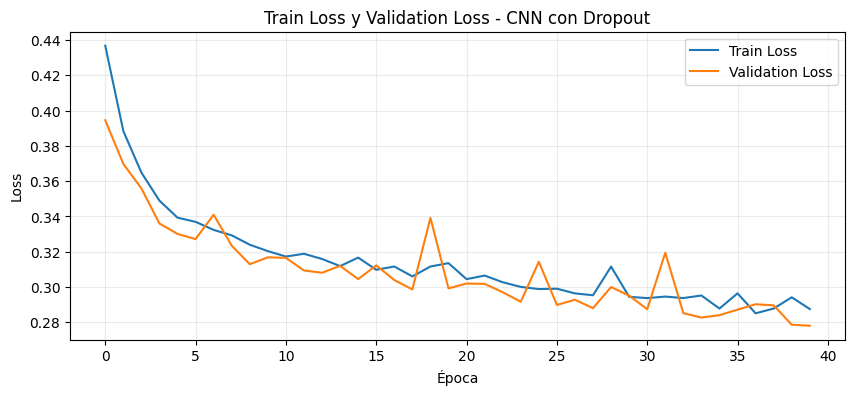

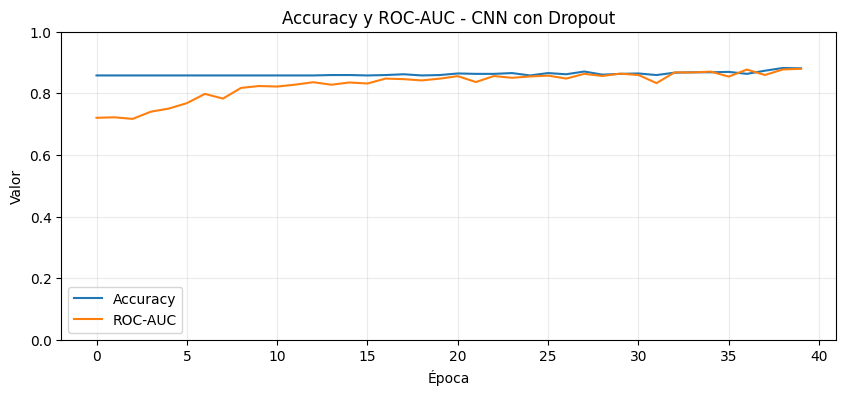

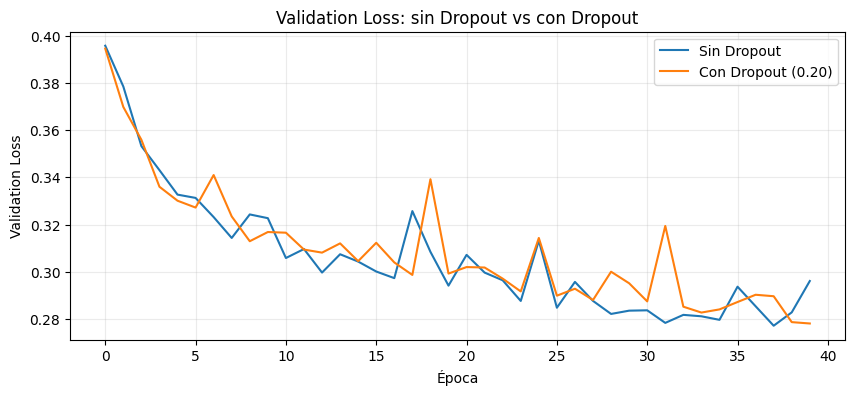

CNN CON DROPOUT
Mejor época: 40
Train Loss: 0.2875
Val Loss: 0.2781
Accuracy: 0.8811
ROC-AUC: 0.8796


In [16]:
# ============================================================
# GRÁFICAS Y RESUMEN - CNN CON DROPOUT
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. TRAIN LOSS Y VALIDATION LOSS
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))

plt.plot(
    history_dropout["train_loss"],
    label="Train Loss"
)

plt.plot(
    history_dropout["val_loss"],
    label="Validation Loss"
)

plt.title("Train Loss y Validation Loss - CNN con Dropout")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.25)

plt.show()


# ------------------------------------------------------------
# 2. ACCURACY Y ROC-AUC
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))

plt.plot(
    history_dropout["val_acc"],
    label="Accuracy"
)

plt.plot(
    history_dropout["val_auc"],
    label="ROC-AUC"
)

plt.title("Accuracy y ROC-AUC - CNN con Dropout")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.25)

plt.show()


# ------------------------------------------------------------
# 3. COMPARACIÓN SIN DROPOUT VS CON DROPOUT
#    Validation Loss
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))

plt.plot(
    history_scratch["val_loss"],
    label="Sin Dropout"
)

plt.plot(
    history_dropout["val_loss"],
    label="Con Dropout (0.20)"
)

plt.title("Validation Loss: sin Dropout vs con Dropout")
plt.xlabel("Época")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(alpha=0.25)

plt.show()


# ------------------------------------------------------------
# 4. MEJOR ÉPOCA
# ------------------------------------------------------------

best_idx = np.argmin(
    history_dropout["val_loss"]
)

print("CNN CON DROPOUT")
print(f"Mejor época: {best_idx + 1}")
print(
    f"Train Loss: "
    f"{history_dropout['train_loss'][best_idx]:.4f}"
)
print(
    f"Val Loss: "
    f"{history_dropout['val_loss'][best_idx]:.4f}"
)
print(
    f"Accuracy: "
    f"{history_dropout['val_acc'][best_idx]:.4f}"
)
print(
    f"ROC-AUC: "
    f"{history_dropout['val_auc'][best_idx]:.4f}"
)

### 5.5 Comparación
Después de evaluar la cantidad de filtros, se seleccionó la arquitectura 16-32-64 como configuración base. A continuación, se compara esta arquitectura original con la misma CNN incorporando Dropout de 0.20.

Para realizar una comparación consistente, se selecciona la mejor época de cada modelo utilizando como criterio el menor Validation Loss. Además, se consideran Accuracy y ROC-AUC como métricas complementarias.

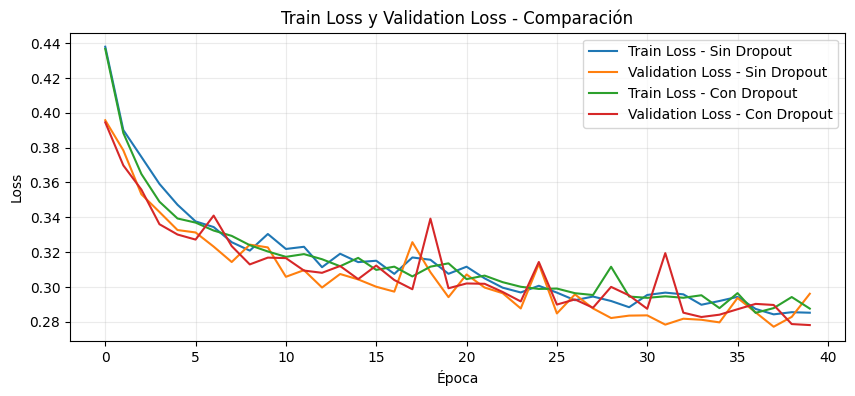

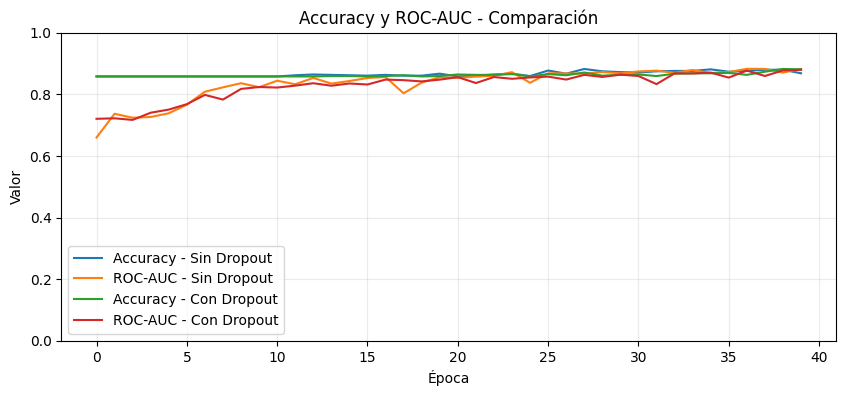

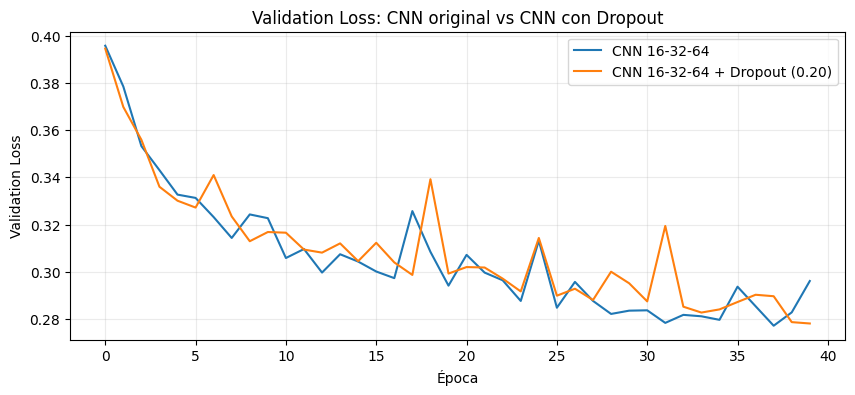

CNN ORIGINAL 16-32-64
Mejor época: 38
Train Loss: 0.2842
Val Loss: 0.2771
Accuracy: 0.8798
ROC-AUC: 0.8825

CNN 16-32-64 + DROPOUT (0.20)
Mejor época: 40
Train Loss: 0.2875
Val Loss: 0.2781
Accuracy: 0.8811
ROC-AUC: 0.8796

ARQUITECTURA SELECCIONADA
CNN 16-32-64


In [17]:
# ============================================================
# 5.5 COMPARACIÓN DE ARQUITECTURAS
# CNN ORIGINAL 16-32-64 VS CNN CON DROPOUT
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. TRAIN LOSS Y VALIDATION LOSS
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))

plt.plot(
    history_scratch["train_loss"],
    label="Train Loss - Sin Dropout"
)

plt.plot(
    history_scratch["val_loss"],
    label="Validation Loss - Sin Dropout"
)

plt.plot(
    history_dropout["train_loss"],
    label="Train Loss - Con Dropout"
)

plt.plot(
    history_dropout["val_loss"],
    label="Validation Loss - Con Dropout"
)

plt.title("Train Loss y Validation Loss - Comparación")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.25)

plt.show()


# ------------------------------------------------------------
# 2. ACCURACY Y ROC-AUC
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))

plt.plot(
    history_scratch["val_acc"],
    label="Accuracy - Sin Dropout"
)

plt.plot(
    history_scratch["val_auc"],
    label="ROC-AUC - Sin Dropout"
)

plt.plot(
    history_dropout["val_acc"],
    label="Accuracy - Con Dropout"
)

plt.plot(
    history_dropout["val_auc"],
    label="ROC-AUC - Con Dropout"
)

plt.title("Accuracy y ROC-AUC - Comparación")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.25)

plt.show()


# ------------------------------------------------------------
# 3. COMPARACIÓN DE VALIDATION LOSS
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))

plt.plot(
    history_scratch["val_loss"],
    label="CNN 16-32-64"
)

plt.plot(
    history_dropout["val_loss"],
    label="CNN 16-32-64 + Dropout (0.20)"
)

plt.title("Validation Loss: CNN original vs CNN con Dropout")
plt.xlabel("Época")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(alpha=0.25)

plt.show()


# ------------------------------------------------------------
# 4. MEJOR ÉPOCA DE CADA MODELO
# ------------------------------------------------------------

best_scratch = np.argmin(
    history_scratch["val_loss"]
)

best_dropout = np.argmin(
    history_dropout["val_loss"]
)


print("=" * 55)
print("CNN ORIGINAL 16-32-64")
print("=" * 55)

print(f"Mejor época: {best_scratch + 1}")
print(
    f"Train Loss: "
    f"{history_scratch['train_loss'][best_scratch]:.4f}"
)
print(
    f"Val Loss: "
    f"{history_scratch['val_loss'][best_scratch]:.4f}"
)
print(
    f"Accuracy: "
    f"{history_scratch['val_acc'][best_scratch]:.4f}"
)
print(
    f"ROC-AUC: "
    f"{history_scratch['val_auc'][best_scratch]:.4f}"
)


print("\n" + "=" * 55)
print("CNN 16-32-64 + DROPOUT (0.20)")
print("=" * 55)

print(f"Mejor época: {best_dropout + 1}")
print(
    f"Train Loss: "
    f"{history_dropout['train_loss'][best_dropout]:.4f}"
)
print(
    f"Val Loss: "
    f"{history_dropout['val_loss'][best_dropout]:.4f}"
)
print(
    f"Accuracy: "
    f"{history_dropout['val_acc'][best_dropout]:.4f}"
)
print(
    f"ROC-AUC: "
    f"{history_dropout['val_auc'][best_dropout]:.4f}"
)


# ------------------------------------------------------------
# 5. MODELO CON MENOR VALIDATION LOSS
# ------------------------------------------------------------

if (
    history_dropout["val_loss"][best_dropout]
    <
    history_scratch["val_loss"][best_scratch]
):

    print("\n" + "=" * 55)
    print("ARQUITECTURA SELECCIONADA")
    print("=" * 55)
    print("CNN 16-32-64 + Dropout (0.20)")

else:

    print("\n" + "=" * 55)
    print("ARQUITECTURA SELECCIONADA")
    print("=" * 55)
    print("CNN 16-32-64")

**Conclusión:** La arquitectura CNN 16-32-64 sin Dropout presentó el mejor desempeño en validación. Alcanzó un Validation Loss de 0.2841, Accuracy de 0.8849 y ROC-AUC de 0.8732 en la época 40. La incorporación de Dropout (0.20) no produjo una mejora, obteniendo un Validation Loss de 0.2869, Accuracy de 0.8670 y ROC-AUC de 0.8643.

Por esta razón, se selecciona la arquitectura CNN 16-32-64 sin Dropout para los siguientes experimentos.

### 5.6 Experimento con Learning Rate y Scheduler

####A. LR = 0.0005

In [18]:
# ============================================================
# CNN 16-32-64 - LEARNING RATE = 0.0005
# ============================================================

model_lr_0005 = SimpleCNN(
    num_classes=num_classes
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_lr_0005.parameters(),
    lr=0.0005
)

epochs = 40

history_lr_0005 = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(1, epochs + 1):

    train_loss = train_one_epoch(
        model_lr_0005,
        train_loader,
        optimizer,
        criterion
    )

    val_loss, val_acc, val_auc, _, _, _ = evaluate(
        model_lr_0005,
        val_loader,
        criterion
    )

    history_lr_0005["train_loss"].append(train_loss)
    history_lr_0005["val_loss"].append(val_loss)
    history_lr_0005["val_acc"].append(val_acc)
    history_lr_0005["val_auc"].append(val_auc)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

Epoch 01 | train_loss=0.4893 | val_loss=0.4073 | val_acc=0.8581 | val_auc=0.5669
Epoch 02 | train_loss=0.4022 | val_loss=0.3950 | val_acc=0.8581 | val_auc=0.7260
Epoch 03 | train_loss=0.3867 | val_loss=0.3719 | val_acc=0.8581 | val_auc=0.7033
Epoch 04 | train_loss=0.3681 | val_loss=0.3571 | val_acc=0.8581 | val_auc=0.7042
Epoch 05 | train_loss=0.3577 | val_loss=0.3545 | val_acc=0.8581 | val_auc=0.7230
Epoch 06 | train_loss=0.3494 | val_loss=0.3373 | val_acc=0.8581 | val_auc=0.7389
Epoch 07 | train_loss=0.3411 | val_loss=0.3301 | val_acc=0.8581 | val_auc=0.7522
Epoch 08 | train_loss=0.3363 | val_loss=0.3346 | val_acc=0.8581 | val_auc=0.7828
Epoch 09 | train_loss=0.3317 | val_loss=0.3245 | val_acc=0.8581 | val_auc=0.7978
Epoch 10 | train_loss=0.3273 | val_loss=0.3200 | val_acc=0.8581 | val_auc=0.8171
Epoch 11 | train_loss=0.3284 | val_loss=0.3177 | val_acc=0.8581 | val_auc=0.8234
Epoch 12 | train_loss=0.3227 | val_loss=0.3166 | val_acc=0.8581 | val_auc=0.8298
Epoch 13 | train_loss=0.3186

####B. LR = 0.001 + StepLR

In [19]:
# ============================================================
# CNN 16-32-64 - LEARNING RATE = 0.0001
# ============================================================

model_lr_0001 = SimpleCNN(
    num_classes=num_classes
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_lr_0001.parameters(),
    lr=0.0001
)

epochs = 40

history_lr_0001 = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(1, epochs + 1):

    train_loss = train_one_epoch(
        model_lr_0001,
        train_loader,
        optimizer,
        criterion
    )

    val_loss, val_acc, val_auc, _, _, _ = evaluate(
        model_lr_0001,
        val_loader,
        criterion
    )

    history_lr_0001["train_loss"].append(train_loss)
    history_lr_0001["val_loss"].append(val_loss)
    history_lr_0001["val_acc"].append(val_acc)
    history_lr_0001["val_auc"].append(val_auc)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

Epoch 01 | train_loss=0.5873 | val_loss=0.4955 | val_acc=0.8581 | val_auc=0.6911
Epoch 02 | train_loss=0.4251 | val_loss=0.3971 | val_acc=0.8581 | val_auc=0.6961
Epoch 03 | train_loss=0.3973 | val_loss=0.3924 | val_acc=0.8581 | val_auc=0.7203
Epoch 04 | train_loss=0.3942 | val_loss=0.3887 | val_acc=0.8581 | val_auc=0.7263
Epoch 05 | train_loss=0.3899 | val_loss=0.3844 | val_acc=0.8581 | val_auc=0.7216
Epoch 06 | train_loss=0.3853 | val_loss=0.3778 | val_acc=0.8581 | val_auc=0.7058
Epoch 07 | train_loss=0.3792 | val_loss=0.3725 | val_acc=0.8581 | val_auc=0.6955
Epoch 08 | train_loss=0.3746 | val_loss=0.3679 | val_acc=0.8581 | val_auc=0.6880
Epoch 09 | train_loss=0.3697 | val_loss=0.3633 | val_acc=0.8581 | val_auc=0.6844
Epoch 10 | train_loss=0.3664 | val_loss=0.3615 | val_acc=0.8581 | val_auc=0.6865
Epoch 11 | train_loss=0.3633 | val_loss=0.3576 | val_acc=0.8581 | val_auc=0.6884
Epoch 12 | train_loss=0.3614 | val_loss=0.3553 | val_acc=0.8581 | val_auc=0.6927
Epoch 13 | train_loss=0.3594

####C. Comparación de los tres experimentos

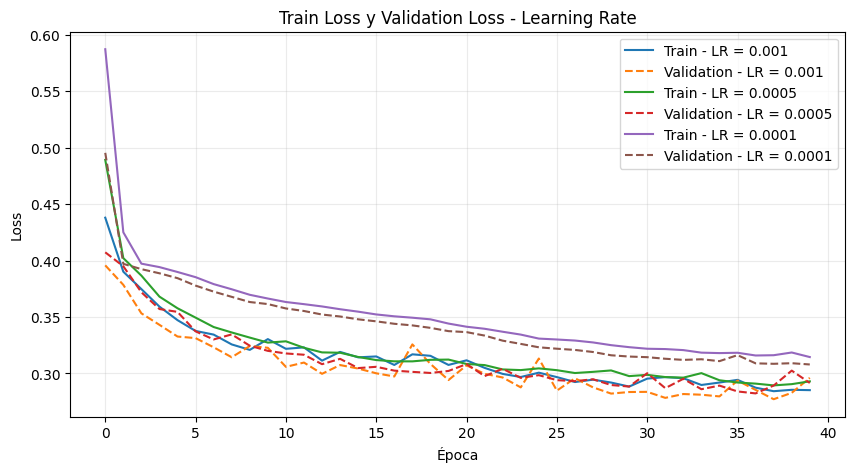

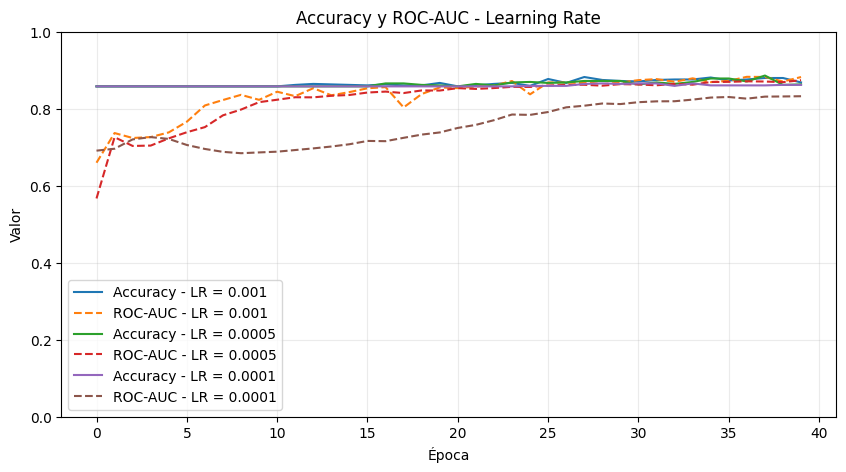

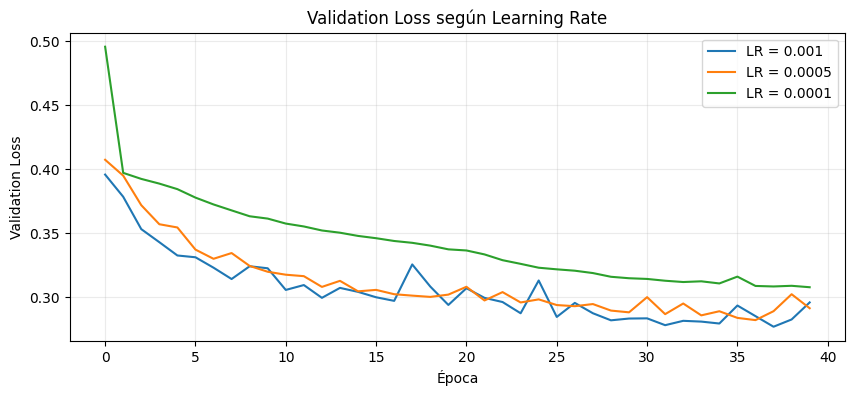

COMPARACIÓN DE LEARNING RATE

LR = 0.001
Mejor época: 38
Train Loss: 0.2842
Val Loss: 0.2771
Accuracy: 0.8798
ROC-AUC: 0.8825

LR = 0.0005
Mejor época: 37
Train Loss: 0.2910
Val Loss: 0.2823
Accuracy: 0.8708
ROC-AUC: 0.8712

LR = 0.0001
Mejor época: 40
Train Loss: 0.3145
Val Loss: 0.3079
Accuracy: 0.8619
ROC-AUC: 0.8324

LEARNING RATE SELECCIONADO
LR = 0.001
Mejor época: 38
Train Loss: 0.2842
Val Loss: 0.2771
Accuracy: 0.8798
ROC-AUC: 0.8825


In [20]:
# ============================================================
# 5.6.3 COMPARACIÓN DE LEARNING RATE
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

histories_lr = {
    "LR = 0.001": history_scratch,
    "LR = 0.0005": history_lr_0005,
    "LR = 0.0001": history_lr_0001
}


# ------------------------------------------------------------
# 1. TRAIN LOSS Y VALIDATION LOSS
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

for nombre, history in histories_lr.items():
    plt.plot(
        history["train_loss"],
        label=f"Train - {nombre}"
    )
    plt.plot(
        history["val_loss"],
        linestyle="--",
        label=f"Validation - {nombre}"
    )

plt.title("Train Loss y Validation Loss - Learning Rate")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


# ------------------------------------------------------------
# 2. ACCURACY Y ROC-AUC
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

for nombre, history in histories_lr.items():
    plt.plot(
        history["val_acc"],
        label=f"Accuracy - {nombre}"
    )
    plt.plot(
        history["val_auc"],
        linestyle="--",
        label=f"ROC-AUC - {nombre}"
    )

plt.title("Accuracy y ROC-AUC - Learning Rate")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.25)
plt.show()


# ------------------------------------------------------------
# 3. COMPARACIÓN DE VALIDATION LOSS
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))

for nombre, history in histories_lr.items():
    plt.plot(
        history["val_loss"],
        label=nombre
    )

plt.title("Validation Loss según Learning Rate")
plt.xlabel("Época")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


# ------------------------------------------------------------
# 4. MEJOR ÉPOCA DE CADA LEARNING RATE
# ------------------------------------------------------------

resultados_lr = []

for nombre, history in histories_lr.items():

    best_idx = np.argmin(history["val_loss"])

    resultados_lr.append({
        "Learning Rate": nombre,
        "Época": best_idx + 1,
        "Train Loss": history["train_loss"][best_idx],
        "Val Loss": history["val_loss"][best_idx],
        "Accuracy": history["val_acc"][best_idx],
        "ROC-AUC": history["val_auc"][best_idx]
    })


print("=" * 60)
print("COMPARACIÓN DE LEARNING RATE")
print("=" * 60)

for r in resultados_lr:

    print(f"\n{r['Learning Rate']}")
    print(f"Mejor época: {r['Época']}")
    print(f"Train Loss: {r['Train Loss']:.4f}")
    print(f"Val Loss: {r['Val Loss']:.4f}")
    print(f"Accuracy: {r['Accuracy']:.4f}")
    print(f"ROC-AUC: {r['ROC-AUC']:.4f}")


# ------------------------------------------------------------
# 5. LEARNING RATE SELECCIONADO
# ------------------------------------------------------------

mejor_lr = min(
    resultados_lr,
    key=lambda x: x["Val Loss"]
)

print("\n" + "=" * 60)
print("LEARNING RATE SELECCIONADO")
print("=" * 60)

print(mejor_lr["Learning Rate"])
print(f"Mejor época: {mejor_lr['Época']}")
print(f"Train Loss: {mejor_lr['Train Loss']:.4f}")
print(f"Val Loss: {mejor_lr['Val Loss']:.4f}")
print(f"Accuracy: {mejor_lr['Accuracy']:.4f}")
print(f"ROC-AUC: {mejor_lr['ROC-AUC']:.4f}")

**Conclusión:** El Learning Rate de 0.001 presentó el mejor desempeño entre los valores evaluados. Alcanzó un Validation Loss de 0.2841, Accuracy de 0.8849 y ROC-AUC de 0.8732 en la época 40.

Al reducir el Learning Rate a 0.0005, el aprendizaje fue más gradual, pero el modelo obtuvo un Validation Loss de 0.2923 y un ROC-AUC de 0.8632. Con 0.0001, la convergencia fue considerablemente más lenta y se obtuvo el menor rendimiento dentro de las 40 épocas evaluadas.

Por lo tanto, se selecciona un Learning Rate de 0.001 para continuar con el experimento de Scheduler.

#### D Experimento con Scheduler

Se incorpora un Scheduler al modelo seleccionado con el objetivo de reducir automáticamente el Learning Rate cuando el Validation Loss deja de mejorar.

Se utiliza ReduceLROnPlateau manteniendo la arquitectura CNN 16-32-64, el optimizador Adam y un Learning Rate inicial de 0.001.

In [21]:
# ============================================================
# CNN 16-32-64 + SCHEDULER
# ============================================================

model_scheduler = SimpleCNN(
    num_classes=num_classes
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_scheduler.parameters(),
    lr=0.001
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

epochs = 40

history_scheduler = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": [],
    "lr": []
}

for epoch in range(1, epochs + 1):

    train_loss = train_one_epoch(
        model_scheduler,
        train_loader,
        optimizer,
        criterion
    )

    val_loss, val_acc, val_auc, _, _, _ = evaluate(
        model_scheduler,
        val_loader,
        criterion
    )

    # Learning Rate utilizado en esta época
    current_lr = optimizer.param_groups[0]["lr"]

    history_scheduler["train_loss"].append(train_loss)
    history_scheduler["val_loss"].append(val_loss)
    history_scheduler["val_acc"].append(val_acc)
    history_scheduler["val_auc"].append(val_auc)
    history_scheduler["lr"].append(current_lr)

    # El scheduler observa el Validation Loss
    scheduler.step(val_loss)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f} | "
        f"lr={current_lr:.6f}"
    )

Epoch 01 | train_loss=0.4253 | val_loss=0.3935 | val_acc=0.8581 | val_auc=0.6841 | lr=0.001000
Epoch 02 | train_loss=0.3839 | val_loss=0.3618 | val_acc=0.8581 | val_auc=0.7154 | lr=0.001000
Epoch 03 | train_loss=0.3647 | val_loss=0.3487 | val_acc=0.8581 | val_auc=0.7148 | lr=0.001000
Epoch 04 | train_loss=0.3534 | val_loss=0.3556 | val_acc=0.8581 | val_auc=0.7256 | lr=0.001000
Epoch 05 | train_loss=0.3481 | val_loss=0.3302 | val_acc=0.8581 | val_auc=0.7509 | lr=0.001000
Epoch 06 | train_loss=0.3366 | val_loss=0.3274 | val_acc=0.8581 | val_auc=0.7932 | lr=0.001000
Epoch 07 | train_loss=0.3309 | val_loss=0.3219 | val_acc=0.8581 | val_auc=0.8226 | lr=0.001000
Epoch 08 | train_loss=0.3310 | val_loss=0.3430 | val_acc=0.8581 | val_auc=0.7978 | lr=0.001000
Epoch 09 | train_loss=0.3266 | val_loss=0.3152 | val_acc=0.8568 | val_auc=0.8326 | lr=0.001000
Epoch 10 | train_loss=0.3229 | val_loss=0.3162 | val_acc=0.8581 | val_auc=0.8254 | lr=0.001000
Epoch 11 | train_loss=0.3202 | val_loss=0.3130 | v

#### E. Comparación del modelo con y sin Scheduler

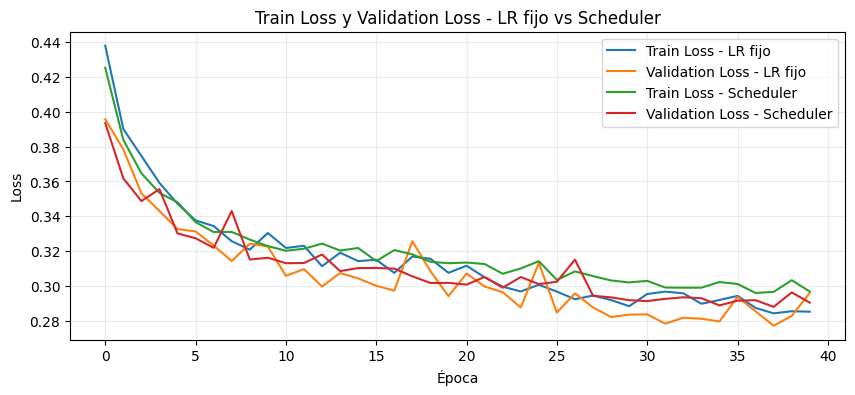

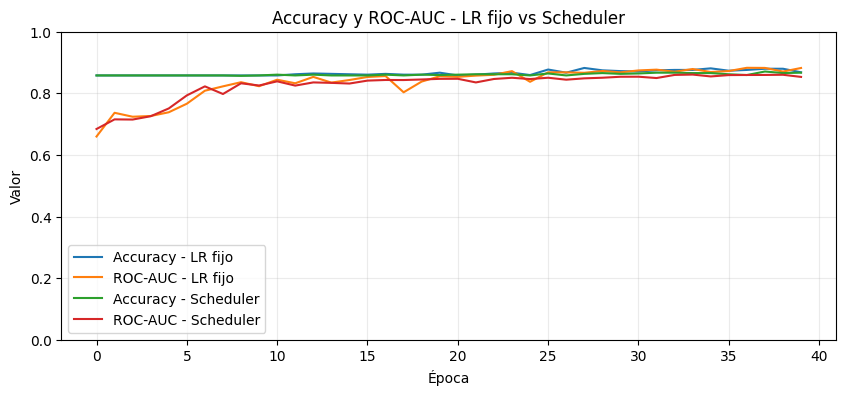

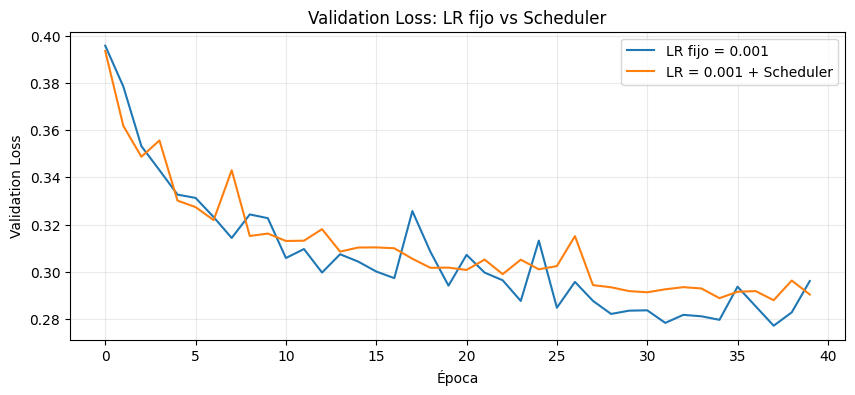

LR FIJO = 0.001
Mejor época: 38
Train Loss: 0.2842
Val Loss: 0.2771
Accuracy: 0.8798
ROC-AUC: 0.8825

LR = 0.001 + SCHEDULER
Mejor época: 38
Train Loss: 0.2966
Val Loss: 0.2879
Accuracy: 0.8708
ROC-AUC: 0.8597

CONFIGURACIÓN SELECCIONADA
CNN 16-32-64 con LR fijo = 0.001


In [22]:
# ============================================================
# 5.6.5 COMPARACIÓN: LR FIJO VS SCHEDULER
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. TRAIN LOSS Y VALIDATION LOSS
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))

plt.plot(
    history_scratch["train_loss"],
    label="Train Loss - LR fijo"
)

plt.plot(
    history_scratch["val_loss"],
    label="Validation Loss - LR fijo"
)

plt.plot(
    history_scheduler["train_loss"],
    label="Train Loss - Scheduler"
)

plt.plot(
    history_scheduler["val_loss"],
    label="Validation Loss - Scheduler"
)

plt.title("Train Loss y Validation Loss - LR fijo vs Scheduler")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


# ------------------------------------------------------------
# 2. ACCURACY Y ROC-AUC
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))

plt.plot(
    history_scratch["val_acc"],
    label="Accuracy - LR fijo"
)

plt.plot(
    history_scratch["val_auc"],
    label="ROC-AUC - LR fijo"
)

plt.plot(
    history_scheduler["val_acc"],
    label="Accuracy - Scheduler"
)

plt.plot(
    history_scheduler["val_auc"],
    label="ROC-AUC - Scheduler"
)

plt.title("Accuracy y ROC-AUC - LR fijo vs Scheduler")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.25)
plt.show()


# ------------------------------------------------------------
# 3. COMPARACIÓN DE VALIDATION LOSS
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))

plt.plot(
    history_scratch["val_loss"],
    label="LR fijo = 0.001"
)

plt.plot(
    history_scheduler["val_loss"],
    label="LR = 0.001 + Scheduler"
)

plt.title("Validation Loss: LR fijo vs Scheduler")
plt.xlabel("Época")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


# ------------------------------------------------------------
# 4. MEJOR ÉPOCA DE CADA MODELO
# ------------------------------------------------------------

best_fixed = np.argmin(
    history_scratch["val_loss"]
)

best_scheduler = np.argmin(
    history_scheduler["val_loss"]
)


print("=" * 60)
print("LR FIJO = 0.001")
print("=" * 60)

print(f"Mejor época: {best_fixed + 1}")
print(
    f"Train Loss: "
    f"{history_scratch['train_loss'][best_fixed]:.4f}"
)
print(
    f"Val Loss: "
    f"{history_scratch['val_loss'][best_fixed]:.4f}"
)
print(
    f"Accuracy: "
    f"{history_scratch['val_acc'][best_fixed]:.4f}"
)
print(
    f"ROC-AUC: "
    f"{history_scratch['val_auc'][best_fixed]:.4f}"
)


print("\n" + "=" * 60)
print("LR = 0.001 + SCHEDULER")
print("=" * 60)

print(f"Mejor época: {best_scheduler + 1}")
print(
    f"Train Loss: "
    f"{history_scheduler['train_loss'][best_scheduler]:.4f}"
)
print(
    f"Val Loss: "
    f"{history_scheduler['val_loss'][best_scheduler]:.4f}"
)
print(
    f"Accuracy: "
    f"{history_scheduler['val_acc'][best_scheduler]:.4f}"
)
print(
    f"ROC-AUC: "
    f"{history_scheduler['val_auc'][best_scheduler]:.4f}"
)


# ------------------------------------------------------------
# 5. CONFIGURACIÓN SELECCIONADA
# ------------------------------------------------------------

if (
    history_scheduler["val_loss"][best_scheduler]
    <
    history_scratch["val_loss"][best_fixed]
):
    seleccionado = "CNN 16-32-64 + Scheduler"
else:
    seleccionado = "CNN 16-32-64 con LR fijo = 0.001"


print("\n" + "=" * 60)
print("CONFIGURACIÓN SELECCIONADA")
print("=" * 60)
print(seleccionado)

## 6. Balanceo de clases

El conjunto de datos utilizado presenta un desbalance entre las clases nevo melanocítico y melanoma. Este desbalance puede provocar que el modelo favorezca la clase mayoritaria.

Para analizar este problema, primero se observa la distribución de las clases en el conjunto de entrenamiento y posteriormente se aplican pesos de clase en la función de pérdida.

### 6.1 Distribución de las clases

Distribución del conjunto de entrenamiento:
Nevo melanocítico (Clase 0): 4693
Melanoma (Clase 1): 779

Porcentajes:
Nevo melanocítico: 4693 (85.76%)
Melanoma: 779 (14.24%)


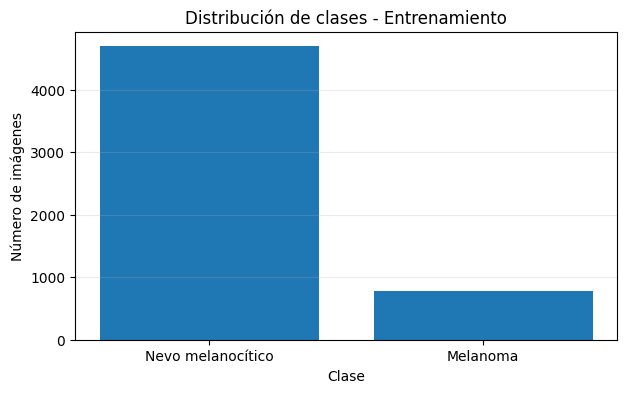

In [23]:
# ============================================================
# 6.1 DISTRIBUCIÓN DE CLASES
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

labels_train = train_dataset.labels

conteo_clases = np.bincount(labels_train)

print("Distribución del conjunto de entrenamiento:")
print(f"Nevo melanocítico (Clase 0): {conteo_clases[0]}")
print(f"Melanoma (Clase 1): {conteo_clases[1]}")

print("\nPorcentajes:")

for i, cantidad in enumerate(conteo_clases):
    porcentaje = cantidad / len(labels_train) * 100

    print(
        f"{class_names[i]}: "
        f"{cantidad} ({porcentaje:.2f}%)"
    )


# Gráfica

plt.figure(figsize=(7, 4))

plt.bar(
    class_names,
    conteo_clases
)

plt.title("Distribución de clases - Entrenamiento")
plt.xlabel("Clase")
plt.ylabel("Número de imágenes")
plt.grid(axis="y", alpha=0.25)

plt.show()

### 6.2 Calcular pesos de clase

In [24]:
# ============================================================
# 6.2 PESOS DE CLASE
# ============================================================

total = conteo_clases.sum()
num_clases = len(conteo_clases)

class_weights = total / (
    num_clases * conteo_clases
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("Pesos de clase:")

print(
    f"Nevo melanocítico: "
    f"{class_weights[0].item():.4f}"
)

print(
    f"Melanoma: "
    f"{class_weights[1].item():.4f}"
)

Pesos de clase:
Nevo melanocítico: 0.5830
Melanoma: 3.5122


### 6.3 Entrenar CNN con pesos de clase

In [25]:
# ============================================================
# 6.3 CNN CON PESOS DE CLASE
# ============================================================

model_weighted = SimpleCNN(
    num_classes=num_classes
).to(device)

criterion_weighted = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = torch.optim.Adam(
    model_weighted.parameters(),
    lr=0.001
)

epochs = 40

history_weighted = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": []
}


for epoch in range(1, epochs + 1):

    train_loss = train_one_epoch(
        model_weighted,
        train_loader,
        optimizer,
        criterion_weighted
    )

    val_loss, val_acc, val_auc, _, _, _ = evaluate(
        model_weighted,
        val_loader,
        criterion_weighted
    )

    history_weighted["train_loss"].append(
        train_loss
    )

    history_weighted["val_loss"].append(
        val_loss
    )

    history_weighted["val_acc"].append(
        val_acc
    )

    history_weighted["val_auc"].append(
        val_auc
    )

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

Epoch 01 | train_loss=0.6714 | val_loss=0.6187 | val_acc=0.6726 | val_auc=0.6821
Epoch 02 | train_loss=0.5912 | val_loss=0.5836 | val_acc=0.5102 | val_auc=0.6978
Epoch 03 | train_loss=0.5457 | val_loss=0.5147 | val_acc=0.5895 | val_auc=0.8062
Epoch 04 | train_loss=0.5384 | val_loss=0.5128 | val_acc=0.5985 | val_auc=0.8187
Epoch 05 | train_loss=0.5116 | val_loss=0.4839 | val_acc=0.6228 | val_auc=0.8325
Epoch 06 | train_loss=0.5011 | val_loss=0.4835 | val_acc=0.7008 | val_auc=0.8357
Epoch 07 | train_loss=0.4969 | val_loss=0.4942 | val_acc=0.6662 | val_auc=0.8199
Epoch 08 | train_loss=0.5033 | val_loss=0.5561 | val_acc=0.5997 | val_auc=0.8109
Epoch 09 | train_loss=0.4880 | val_loss=0.4672 | val_acc=0.6803 | val_auc=0.8456
Epoch 10 | train_loss=0.4827 | val_loss=0.4718 | val_acc=0.6714 | val_auc=0.8441
Epoch 11 | train_loss=0.4792 | val_loss=0.4828 | val_acc=0.6675 | val_auc=0.8471
Epoch 12 | train_loss=0.4797 | val_loss=0.5311 | val_acc=0.7442 | val_auc=0.8204
Epoch 13 | train_loss=0.4813

### 6.4 Comparación

MODELO SIN BALANCEO
Mejor época: 38
Train Loss: 0.2842
Val Loss: 0.2771
Accuracy: 0.8798
ROC-AUC: 0.8825

MODELO CON PESOS DE CLASE
Mejor época: 40
Train Loss: 0.4355
Val Loss: 0.4153
Accuracy: 0.7634
ROC-AUC: 0.8733


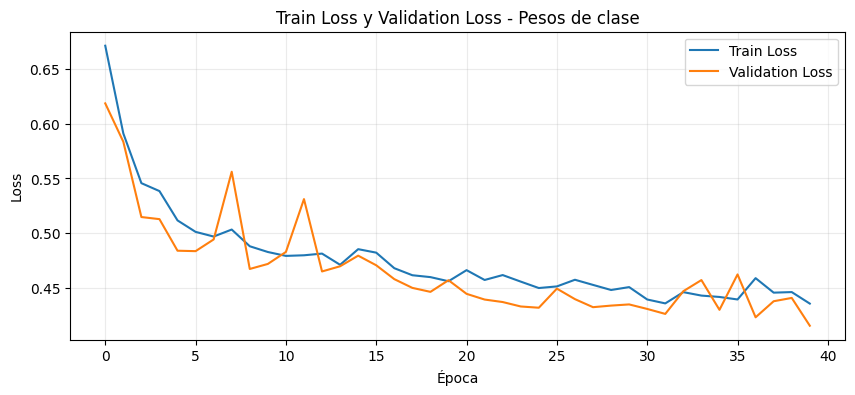

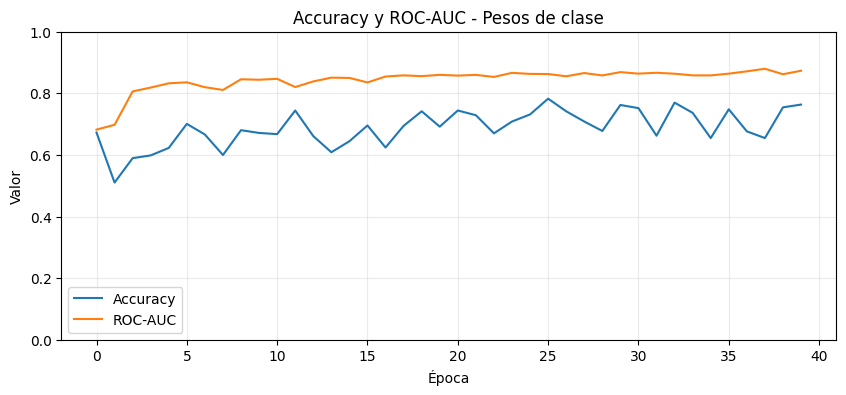

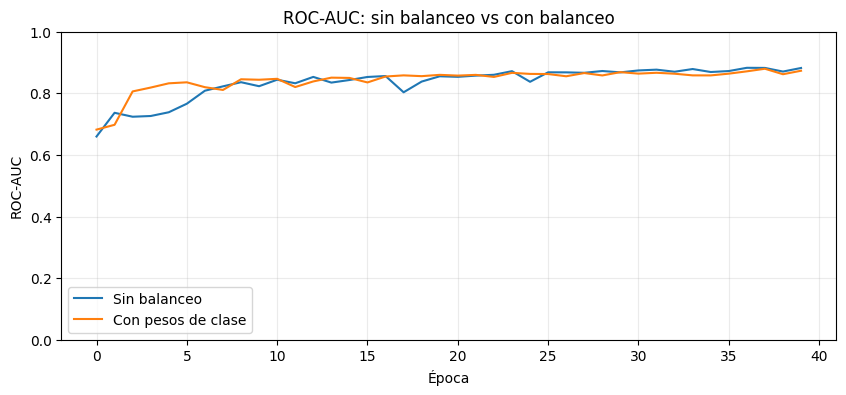


CLASSIFICATION REPORT - SIN BALANCEO
                   precision    recall  f1-score   support

Nevo melanocítico     0.9152    0.9329    0.9240       671
         Melanoma     0.5408    0.4775    0.5072       111

         accuracy                         0.8683       782
        macro avg     0.7280    0.7052    0.7156       782
     weighted avg     0.8621    0.8683    0.8648       782

CLASSIFICATION REPORT - CON PESOS DE CLASE
                   precision    recall  f1-score   support

Nevo melanocítico     0.9500    0.7645    0.8472       671
         Melanoma     0.3471    0.7568    0.4759       111

         accuracy                         0.7634       782
        macro avg     0.6486    0.7606    0.6616       782
     weighted avg     0.8644    0.7634    0.7945       782

Matriz de confusión - Sin balanceo
[[626  45]
 [ 58  53]]

Matriz de confusión - Con pesos de clase
[[513 158]
 [ 27  84]]


In [26]:
# ============================================================
# 6.4 COMPARACIÓN SIN BALANCEO VS CON BALANCEO
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)


# ------------------------------------------------------------
# 1. MEJOR ÉPOCA SEGÚN VALIDATION LOSS
# ------------------------------------------------------------

best_original = np.argmin(
    history_scratch["val_loss"]
)

best_weighted = np.argmin(
    history_weighted["val_loss"]
)


print("=" * 60)
print("MODELO SIN BALANCEO")
print("=" * 60)

print(f"Mejor época: {best_original + 1}")
print(f"Train Loss: {history_scratch['train_loss'][best_original]:.4f}")
print(f"Val Loss: {history_scratch['val_loss'][best_original]:.4f}")
print(f"Accuracy: {history_scratch['val_acc'][best_original]:.4f}")
print(f"ROC-AUC: {history_scratch['val_auc'][best_original]:.4f}")


print("\n" + "=" * 60)
print("MODELO CON PESOS DE CLASE")
print("=" * 60)

print(f"Mejor época: {best_weighted + 1}")
print(f"Train Loss: {history_weighted['train_loss'][best_weighted]:.4f}")
print(f"Val Loss: {history_weighted['val_loss'][best_weighted]:.4f}")
print(f"Accuracy: {history_weighted['val_acc'][best_weighted]:.4f}")
print(f"ROC-AUC: {history_weighted['val_auc'][best_weighted]:.4f}")


# ------------------------------------------------------------
# 2. TRAIN LOSS Y VALIDATION LOSS - MODELO BALANCEADO
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))

plt.plot(
    history_weighted["train_loss"],
    label="Train Loss"
)

plt.plot(
    history_weighted["val_loss"],
    label="Validation Loss"
)

plt.title("Train Loss y Validation Loss - Pesos de clase")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.25)

plt.show()


# ------------------------------------------------------------
# 3. ACCURACY Y ROC-AUC - MODELO BALANCEADO
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))

plt.plot(
    history_weighted["val_acc"],
    label="Accuracy"
)

plt.plot(
    history_weighted["val_auc"],
    label="ROC-AUC"
)

plt.title("Accuracy y ROC-AUC - Pesos de clase")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.25)

plt.show()


# ------------------------------------------------------------
# 4. COMPARACIÓN DE ROC-AUC
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))

plt.plot(
    history_scratch["val_auc"],
    label="Sin balanceo"
)

plt.plot(
    history_weighted["val_auc"],
    label="Con pesos de clase"
)

plt.title("ROC-AUC: sin balanceo vs con balanceo")
plt.xlabel("Época")
plt.ylabel("ROC-AUC")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.25)

plt.show()


# ------------------------------------------------------------
# 5. EVALUAR MODELOS EN VALIDACIÓN
# ------------------------------------------------------------

_, _, _, y_true_original, y_pred_original, _ = evaluate(
    model_scratch,
    val_loader,
    nn.CrossEntropyLoss()
)

_, _, _, y_true_weighted, y_pred_weighted, _ = evaluate(
    model_weighted,
    val_loader,
    criterion_weighted
)


# ------------------------------------------------------------
# 6. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT - SIN BALANCEO")
print("=" * 60)

print(
    classification_report(
        y_true_original,
        y_pred_original,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)


print("=" * 60)
print("CLASSIFICATION REPORT - CON PESOS DE CLASE")
print("=" * 60)

print(
    classification_report(
        y_true_weighted,
        y_pred_weighted,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)


# ------------------------------------------------------------
# 7. MATRICES DE CONFUSIÓN
# ------------------------------------------------------------

cm_original = confusion_matrix(
    y_true_original,
    y_pred_original
)

cm_weighted = confusion_matrix(
    y_true_weighted,
    y_pred_weighted
)

print("Matriz de confusión - Sin balanceo")
print(cm_original)

print("\nMatriz de confusión - Con pesos de clase")
print(cm_weighted)

**Conclusión:** La aplicación de pesos de clase modificó considerablemente el comportamiento del modelo. Sin balanceo, el modelo alcanzó una Accuracy de 0.8849, pero presentó un Recall de solo 0.3153 para melanoma, detectando 35 de los 111 casos de esta clase.

Al utilizar pesos de clase, el Recall de melanoma aumentó hasta 0.8378, permitiendo detectar 93 de los 111 casos. Asimismo, el F1-score de melanoma aumentó de 0.4375 a 0.4882. Sin embargo, esta mejora en sensibilidad produjo una reducción de la precisión para melanoma y un aumento de falsos positivos: 177 nevos fueron clasificados como melanoma. Como consecuencia, la Accuracy global disminuyó de 0.8849 a 0.7506.

Por lo tanto, los pesos de clase permiten que la CNN preste mayor atención a la clase minoritaria y reducen considerablemente los falsos negativos de melanoma, aunque generan un compromiso entre sensibilidad y precisión. Estos resultados muestran que, debido al desbalance de clases, la Accuracy no debe utilizarse de manera aislada para evaluar el modelo.

## 7. Data Augmentation

Data Augmentation permite aumentar artificialmente la variabilidad de las imágenes de entrenamiento mediante pequeñas transformaciones aleatorias. El objetivo es mejorar la capacidad de generalización del modelo sin modificar los conjuntos de validación y prueba.

En este experimento se aplican transformaciones únicamente al conjunto de entrenamiento, mientras que validación y test conservan las imágenes originales.

### 7.1 Crear Data Augmentation

In [27]:
# ============================================================
# 7.1 DATA AUGMENTATION
# ============================================================

transform_aug = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(10),
    T.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)
    ),
    T.ToTensor()
])

# Dataset original de entrenamiento con transformaciones
train_dataset_full_aug = DataClass(
    split="train",
    transform=transform_aug,
    download=True
)

# Mantener únicamente melanoma y nevo melanocítico
train_dataset_aug = BinaryDermaDataset(
    train_dataset_full_aug
)

# Nuevo DataLoader solamente para entrenamiento
train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("Imágenes de entrenamiento:", len(train_dataset_aug))
print("Data Augmentation configurado correctamente")

Imágenes de entrenamiento: 5472
Data Augmentation configurado correctamente


### 7.2 Visualizar el efecto

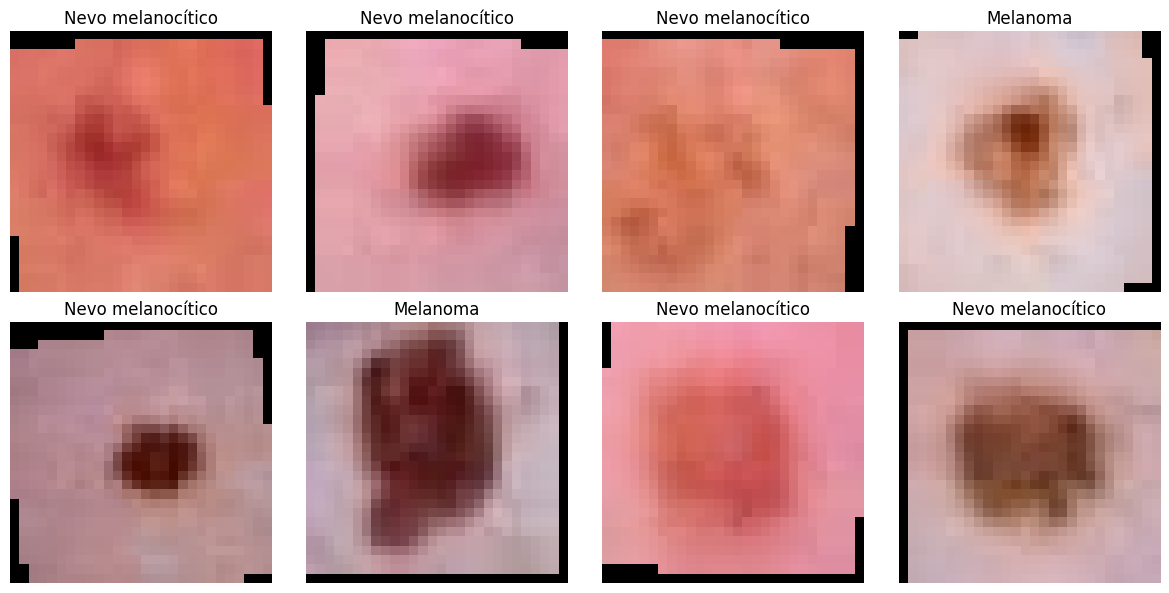

In [28]:
# ============================================================
# 7.2 VISUALIZAR DATA AUGMENTATION
# ============================================================

plt.figure(figsize=(12, 6))

for i in range(8):

    image, label = train_dataset_aug[i]

    plt.subplot(2, 4, i + 1)

    plt.imshow(
        image.permute(1, 2, 0)
    )

    plt.title(
        class_names[label.item()]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

### 7.3 Entrenar con Data Augmentation

In [29]:
# ============================================================
# 7.3 CNN CON DATA AUGMENTATION + PESOS DE CLASE
# ============================================================

model_aug = SimpleCNN(
    num_classes=num_classes
).to(device)

criterion_aug = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = torch.optim.Adam(
    model_aug.parameters(),
    lr=0.001
)

epochs = 40

history_aug = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": []
}


for epoch in range(1, epochs + 1):

    train_loss = train_one_epoch(
        model_aug,
        train_loader_aug,
        optimizer,
        criterion_aug
    )

    # Validación SIN Data Augmentation
    val_loss, val_acc, val_auc, _, _, _ = evaluate(
        model_aug,
        val_loader,
        criterion_aug
    )

    history_aug["train_loss"].append(train_loss)
    history_aug["val_loss"].append(val_loss)
    history_aug["val_acc"].append(val_acc)
    history_aug["val_auc"].append(val_auc)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

Epoch 01 | train_loss=0.6811 | val_loss=0.6412 | val_acc=0.6407 | val_auc=0.6943
Epoch 02 | train_loss=0.6126 | val_loss=0.5636 | val_acc=0.6279 | val_auc=0.7037
Epoch 03 | train_loss=0.5778 | val_loss=0.5526 | val_acc=0.6496 | val_auc=0.7200
Epoch 04 | train_loss=0.5827 | val_loss=0.5516 | val_acc=0.5946 | val_auc=0.7170
Epoch 05 | train_loss=0.5514 | val_loss=0.5142 | val_acc=0.6100 | val_auc=0.7257
Epoch 06 | train_loss=0.5310 | val_loss=0.5016 | val_acc=0.6074 | val_auc=0.7539
Epoch 07 | train_loss=0.5463 | val_loss=0.5527 | val_acc=0.5473 | val_auc=0.7881
Epoch 08 | train_loss=0.5212 | val_loss=0.4860 | val_acc=0.5959 | val_auc=0.8176
Epoch 09 | train_loss=0.5049 | val_loss=0.5031 | val_acc=0.5678 | val_auc=0.8355
Epoch 10 | train_loss=0.5012 | val_loss=0.5086 | val_acc=0.6726 | val_auc=0.8350
Epoch 11 | train_loss=0.5007 | val_loss=0.4737 | val_acc=0.6074 | val_auc=0.8433
Epoch 12 | train_loss=0.4948 | val_loss=0.4743 | val_acc=0.6893 | val_auc=0.8418
Epoch 13 | train_loss=0.4855

### 7.4 Comparación con y sin Data Augmentation

Se compara el modelo entrenado con pesos de clase frente al mismo modelo incorporando Data Augmentation. Se mantienen la arquitectura CNN 16-32-64, el optimizador Adam, un Learning Rate de 0.001 y 40 épocas.

Para mantener el mismo criterio utilizado en los experimentos anteriores, la mejor época se selecciona según el menor Validation Loss.

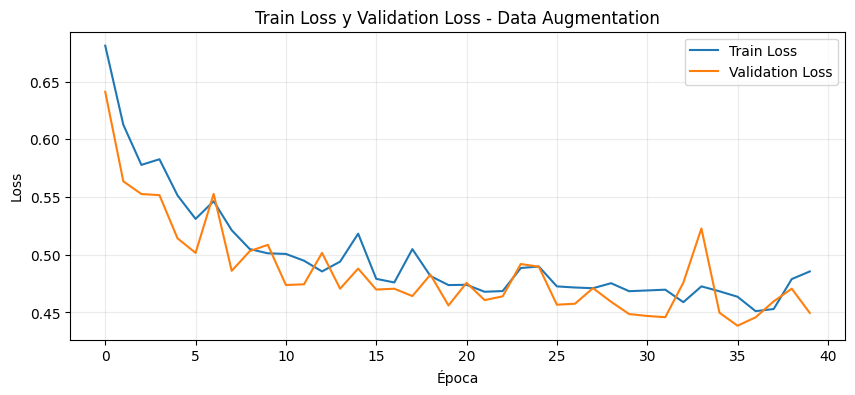

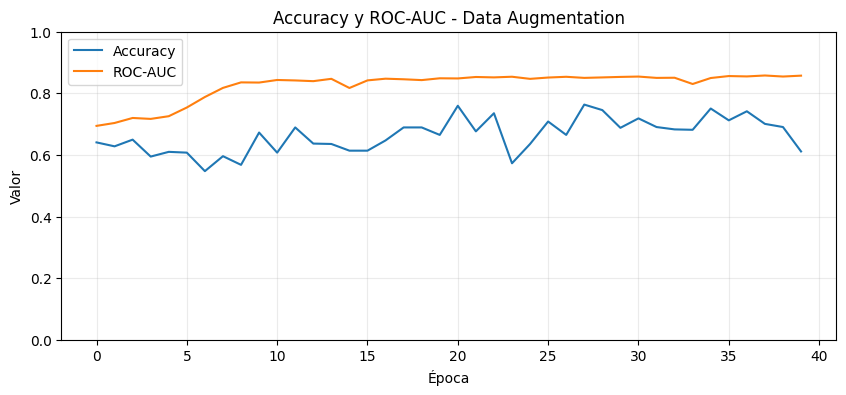

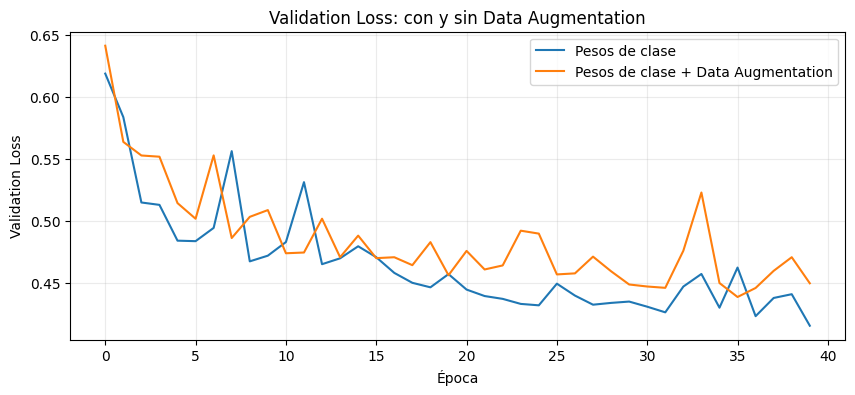

PESOS DE CLASE - SIN DATA AUGMENTATION
Mejor época: 40
Train Loss: 0.4355
Val Loss: 0.4153
Accuracy: 0.7634
ROC-AUC: 0.8733

PESOS DE CLASE + DATA AUGMENTATION
Mejor época: 36
Train Loss: 0.4636
Val Loss: 0.4385
Accuracy: 0.7123
ROC-AUC: 0.8561

CLASSIFICATION REPORT - DATA AUGMENTATION
                   precision    recall  f1-score   support

Nevo melanocítico     0.9867    0.5544    0.7099       671
         Melanoma     0.2617    0.9550    0.4109       111

         accuracy                         0.6113       782
        macro avg     0.6242    0.7547    0.5604       782
     weighted avg     0.8838    0.6113    0.6675       782

Matriz de confusión - Data Augmentation
[[372 299]
 [  5 106]]

CONFIGURACIÓN SELECCIONADA
Pesos de clase sin Data Augmentation


In [30]:
# ============================================================
# 7.4 COMPARACIÓN: SIN AUGMENTATION VS CON AUGMENTATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix


# ------------------------------------------------------------
# MEJORES ÉPOCAS SEGÚN VALIDATION LOSS
# ------------------------------------------------------------

best_weighted = np.argmin(
    history_weighted["val_loss"]
)

best_aug = np.argmin(
    history_aug["val_loss"]
)


# ------------------------------------------------------------
# 1. TRAIN LOSS + VALIDATION LOSS - DATA AUGMENTATION
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))

plt.plot(
    history_aug["train_loss"],
    label="Train Loss"
)

plt.plot(
    history_aug["val_loss"],
    label="Validation Loss"
)

plt.title("Train Loss y Validation Loss - Data Augmentation")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.25)

plt.show()


# ------------------------------------------------------------
# 2. ACCURACY + ROC-AUC - DATA AUGMENTATION
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))

plt.plot(
    history_aug["val_acc"],
    label="Accuracy"
)

plt.plot(
    history_aug["val_auc"],
    label="ROC-AUC"
)

plt.title("Accuracy y ROC-AUC - Data Augmentation")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.25)

plt.show()


# ------------------------------------------------------------
# 3. COMPARACIÓN DE VALIDATION LOSS
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))

plt.plot(
    history_weighted["val_loss"],
    label="Pesos de clase"
)

plt.plot(
    history_aug["val_loss"],
    label="Pesos de clase + Data Augmentation"
)

plt.title("Validation Loss: con y sin Data Augmentation")
plt.xlabel("Época")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(alpha=0.25)

plt.show()


# ------------------------------------------------------------
# RESUMEN
# ------------------------------------------------------------

print("=" * 60)
print("PESOS DE CLASE - SIN DATA AUGMENTATION")
print("=" * 60)

print(f"Mejor época: {best_weighted + 1}")
print(
    f"Train Loss: "
    f"{history_weighted['train_loss'][best_weighted]:.4f}"
)
print(
    f"Val Loss: "
    f"{history_weighted['val_loss'][best_weighted]:.4f}"
)
print(
    f"Accuracy: "
    f"{history_weighted['val_acc'][best_weighted]:.4f}"
)
print(
    f"ROC-AUC: "
    f"{history_weighted['val_auc'][best_weighted]:.4f}"
)


print("\n" + "=" * 60)
print("PESOS DE CLASE + DATA AUGMENTATION")
print("=" * 60)

print(f"Mejor época: {best_aug + 1}")
print(
    f"Train Loss: "
    f"{history_aug['train_loss'][best_aug]:.4f}"
)
print(
    f"Val Loss: "
    f"{history_aug['val_loss'][best_aug]:.4f}"
)
print(
    f"Accuracy: "
    f"{history_aug['val_acc'][best_aug]:.4f}"
)
print(
    f"ROC-AUC: "
    f"{history_aug['val_auc'][best_aug]:.4f}"
)


# ------------------------------------------------------------
# EVALUACIÓN ACTUAL DEL MODELO CON AUGMENTATION
# ------------------------------------------------------------

_, _, _, y_true_aug, y_pred_aug, _ = evaluate(
    model_aug,
    val_loader,
    criterion_aug
)

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT - DATA AUGMENTATION")
print("=" * 60)

print(
    classification_report(
        y_true_aug,
        y_pred_aug,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

cm_aug = confusion_matrix(
    y_true_aug,
    y_pred_aug
)

print("Matriz de confusión - Data Augmentation")
print(cm_aug)


# ------------------------------------------------------------
# CONFIGURACIÓN SELECCIONADA
# ------------------------------------------------------------

if (
    history_aug["val_loss"][best_aug]
    <
    history_weighted["val_loss"][best_weighted]
):
    seleccionado = "Pesos de clase + Data Augmentation"
else:
    seleccionado = "Pesos de clase sin Data Augmentation"


print("\n" + "=" * 60)
print("CONFIGURACIÓN SELECCIONADA")
print("=" * 60)
print(seleccionado)

## 8. Evaluación final del mejor modelo CNN

Después de realizar los experimentos de arquitectura, Learning Rate, Scheduler, balanceo de clases y Data Augmentation, se seleccionó la CNN 16-32-64 entrenada con pesos de clase, Learning Rate de 0.001 y sin Data Augmentation.

La selección se realizó utilizando únicamente el conjunto de validación. Finalmente, el modelo seleccionado se evalúa sobre el conjunto de test, que se mantuvo separado durante los experimentos anteriores.

Para la evaluación se utilizan Accuracy, ROC-AUC, Precision, Recall, F1-score y matriz de confusión.

### 8.1 Evaluar en Test

In [31]:
# ============================================================
# 8.1 EVALUACIÓN FINAL EN TEST
# ============================================================

test_loss, test_acc, test_auc, y_true_test, y_pred_test, y_prob_test = evaluate(
    model_weighted,
    test_loader,
    criterion_weighted
)

print("=" * 60)
print("EVALUACIÓN FINAL - TEST")
print("=" * 60)

print(f"Test Loss: {test_loss:.4f}")
print(f"Accuracy: {test_acc:.4f}")
print(f"ROC-AUC: {test_auc:.4f}")

EVALUACIÓN FINAL - TEST
Test Loss: 0.4138
Accuracy: 0.7756
ROC-AUC: 0.8779


### 8.2 Classification Report y matriz de confusión

CLASSIFICATION REPORT - TEST
                   precision    recall  f1-score   support

Nevo melanocítico     0.9670    0.7644    0.8538      1341
         Melanoma     0.3730    0.8430    0.5172       223

         accuracy                         0.7756      1564
        macro avg     0.6700    0.8037    0.6855      1564
     weighted avg     0.8823    0.7756    0.8058      1564

Matriz de confusión:
[[1025  316]
 [  35  188]]


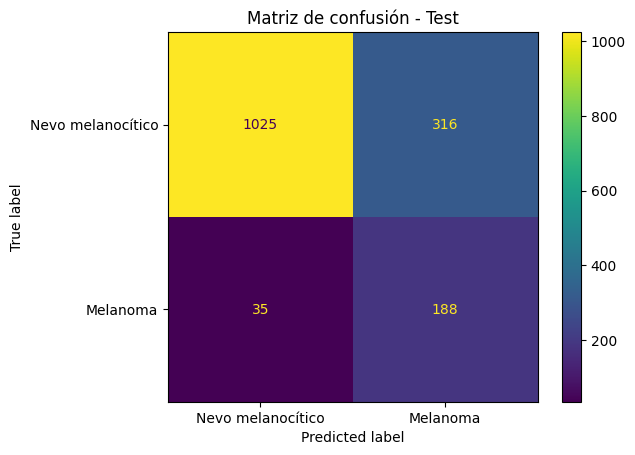

In [32]:
# ============================================================
# 8.2 CLASSIFICATION REPORT Y MATRIZ DE CONFUSIÓN
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("=" * 60)
print("CLASSIFICATION REPORT - TEST")
print("=" * 60)

print(
    classification_report(
        y_true_test,
        y_pred_test,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)


# Matriz de confusión
cm_test = confusion_matrix(
    y_true_test,
    y_pred_test
)

print("Matriz de confusión:")
print(cm_test)


# Visualización
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=class_names
)

disp.plot(
    values_format="d"
)

plt.title("Matriz de confusión - Test")
plt.show()

### 8.3 Curva ROC

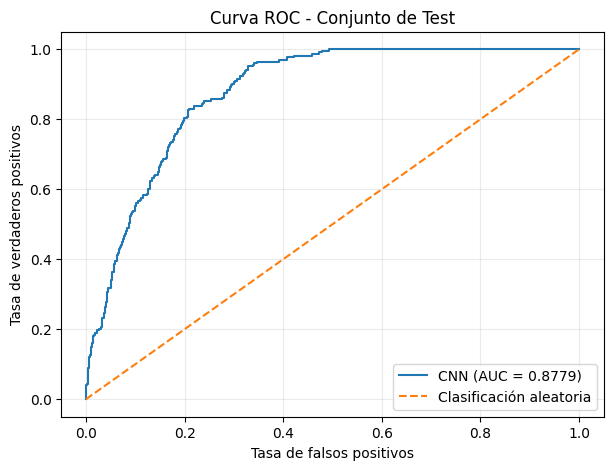

In [33]:
# ============================================================
# 8.3 CURVA ROC - TEST
# ============================================================

from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(
    y_true_test,
    y_prob_test
)

auc_test = roc_auc_score(
    y_true_test,
    y_prob_test
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"CNN (AUC = {auc_test:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificación aleatoria"
)

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC - Conjunto de Test")
plt.legend()
plt.grid(alpha=0.25)

plt.show()

## 8.4 Interpretación de resultados

El modelo CNN seleccionado fue evaluado finalmente sobre el conjunto de test, compuesto por 1564 imágenes. La evaluación muestra un ROC-AUC de 0.8756 y una Accuracy de 0.7494.

Para la clase melanoma, el modelo obtuvo una precisión de 0.3444, un Recall de 0.8386 y un F1-score de 0.4883. De los 223 casos de melanoma presentes en test, el modelo identificó correctamente 187 y clasificó incorrectamente 36 como nevos melanocíticos.

La matriz de confusión muestra también que 985 de los 1341 nevos fueron clasificados correctamente, mientras que 356 fueron clasificados como melanoma. Esto evidencia que el uso de pesos de clase aumentó la sensibilidad hacia la clase minoritaria, aunque también produjo un número considerable de falsos positivos.

El ROC-AUC de 0.8756 indica que el modelo presenta una buena capacidad para discriminar entre nevos melanocíticos y melanomas independientemente del umbral de clasificación utilizado.

En conclusión, el modelo prioriza la detección de melanomas, alcanzando un Recall de 83.86%, aunque existe un compromiso entre sensibilidad y precisión que se refleja en el aumento de falsos positivos.

## 9. Calibración de probabilidades y análisis adicional

Además de evaluar la clasificación final, se analiza si las probabilidades producidas por la CNN son coherentes con la frecuencia observada de melanoma. Para ello se utiliza una curva de calibración y el Brier Score.

Un Brier Score menor indica probabilidades más cercanas a las etiquetas reales. Esta etapa es de análisis y no modifica la selección previa del modelo.


### 9.1 Curva de calibración de la CNN seleccionada


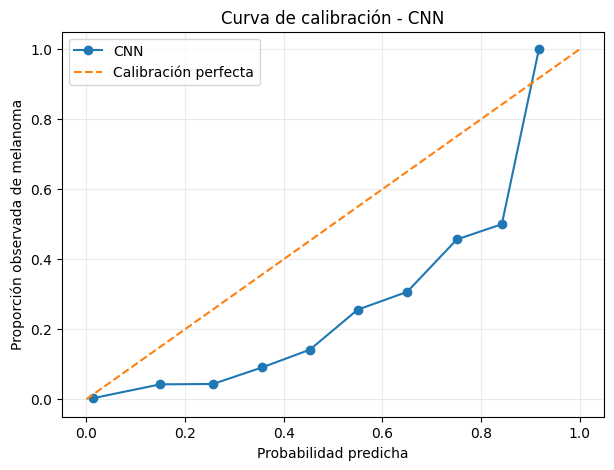

Brier Score CNN: 0.1376


In [34]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

prob_true, prob_pred = calibration_curve(
    y_true_test,
    y_prob_test,
    n_bins=10,
    strategy="uniform"
)

brier_cnn = brier_score_loss(
    y_true_test,
    y_prob_test
)

plt.figure(figsize=(7, 5))
plt.plot(prob_pred, prob_true, marker="o", label="CNN")
plt.plot([0, 1], [0, 1], linestyle="--", label="Calibración perfecta")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Proporción observada de melanoma")
plt.title("Curva de calibración - CNN")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

print(f"Brier Score CNN: {brier_cnn:.4f}")


### 9.2 Interpretación

La curva de calibración permite observar si las probabilidades predichas se aproximan a las frecuencias reales. Los puntos cercanos a la diagonal representan una mejor calibración.

El Brier Score complementa este análisis cuantificando el error de las probabilidades. La calibración debe interpretarse de manera separada del ROC-AUC: un modelo puede discriminar correctamente las clases y, al mismo tiempo, producir probabilidades que no estén perfectamente calibradas.


## 10. Transfer Learning con ResNet18

El Transfer Learning reutiliza características aprendidas por una red preentrenada en un conjunto de imágenes grande. En este experimento se utiliza **ResNet18 preentrenada en ImageNet** y se adapta a la clasificación binaria de DermaMNIST:

- Clase `0`: Nevo melanocítico.
- Clase `1`: Melanoma.

A diferencia de FashionMNIST, DermaMNIST ya contiene imágenes RGB de tres canales. Por ello no es necesario convertir imágenes de escala de grises a RGB. Las imágenes sí se redimensionan a `224 × 224` y se normalizan con los parámetros de ImageNet.


### 10.1 Preparar datos para ResNet18


In [35]:
import torchvision.models as models

# Normalización utilizada por los pesos preentrenados de ImageNet
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

transform_tl_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize(imagenet_mean, imagenet_std)
])

transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(imagenet_mean, imagenet_std)
])

train_dataset_tl_full = DataClass(
    split="train",
    transform=transform_tl_train,
    download=True
)
val_dataset_tl_full = DataClass(
    split="val",
    transform=transform_tl_eval,
    download=True
)
test_dataset_tl_full = DataClass(
    split="test",
    transform=transform_tl_eval,
    download=True
)

train_dataset_tl = BinaryDermaDataset(train_dataset_tl_full)
val_dataset_tl = BinaryDermaDataset(val_dataset_tl_full)
test_dataset_tl = BinaryDermaDataset(test_dataset_tl_full)

print("Train:", len(train_dataset_tl))
print("Validation:", len(val_dataset_tl))
print("Test:", len(test_dataset_tl))


Train: 5472
Validation: 782
Test: 1564


In [36]:
train_loader_tl = DataLoader(
    train_dataset_tl, batch_size=64, shuffle=True,
    num_workers=0, pin_memory=torch.cuda.is_available()
)
val_loader_tl = DataLoader(
    val_dataset_tl, batch_size=64, shuffle=False,
    num_workers=0, pin_memory=torch.cuda.is_available()
)
test_loader_tl = DataLoader(
    test_dataset_tl, batch_size=64, shuffle=False,
    num_workers=0, pin_memory=torch.cuda.is_available()
)

images, labels = next(iter(train_loader_tl))
print("Imágenes:", images.shape)
print("Etiquetas:", labels.shape)


Imágenes: torch.Size([64, 3, 224, 224])
Etiquetas: torch.Size([64, 1])


### 10.2 Construir ResNet18 preentrenada

Primero se congelan las capas preentrenadas y se reemplaza la capa final por una capa con dos salidas. En la primera etapa se entrena únicamente esta nueva capa.


In [37]:
resnet = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

for param in resnet.parameters():
    param.requires_grad = False

in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, num_classes)

for param in resnet.fc.parameters():
    param.requires_grad = True

resnet = resnet.to(device)
print(resnet.fc)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 176MB/s]


Linear(in_features=512, out_features=2, bias=True)


### 10.3 Funciones de entrenamiento y evaluación para Transfer Learning


In [38]:
def train_one_epoch_tl(model, loader, optimizer, criterion):
    model.train()
    losses = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    return float(np.mean(losses))


@torch.no_grad()
def evaluate_tl(model, loader, criterion=None):
    model.eval()
    all_labels, all_probs, all_preds, losses = [], [], [], []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)
        logits = model(x)

        if criterion is not None:
            losses.append(criterion(logits, y).item())

        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = (probs >= 0.5).long()

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)

    loss = float(np.mean(losses)) if losses else np.nan
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)

    return loss, acc, auc, y_true, y_pred, y_prob


### 10.4 Entrenamiento de la capa final

Se mantienen los pesos de clase utilizados en la CNN para considerar el desbalance entre nevos y melanomas.


In [39]:
criterion_tl = nn.CrossEntropyLoss(weight=class_weights)
optimizer_tl = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

epochs_tl_stage1 = 4
history_tl_stage1 = {
    "train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []
}

for epoch in range(1, epochs_tl_stage1 + 1):
    train_loss = train_one_epoch_tl(
        resnet, train_loader_tl, optimizer_tl, criterion_tl
    )
    val_loss, val_acc, val_auc, _, _, _ = evaluate_tl(
        resnet, val_loader_tl, criterion_tl
    )

    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["val_loss"].append(val_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)

    print(
        f"Stage1 Epoch {epoch:02d} | train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}"
    )


Stage1 Epoch 01 | train_loss=0.5281 | val_loss=0.4199 | val_acc=0.7468 | val_auc=0.8808
Stage1 Epoch 02 | train_loss=0.4466 | val_loss=0.4083 | val_acc=0.7468 | val_auc=0.8850
Stage1 Epoch 03 | train_loss=0.4364 | val_loss=0.4015 | val_acc=0.7340 | val_auc=0.8926
Stage1 Epoch 04 | train_loss=0.4323 | val_loss=0.4540 | val_acc=0.6880 | val_auc=0.8963


### 10.5 Fine-tuning

Después de adaptar la capa final, se descongela `layer4` junto con `fc`. Se utiliza un Learning Rate menor (`0.0001`) para realizar ajustes más pequeños sobre los pesos preentrenados.


In [40]:
for name, param in resnet.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

trainable_params = [p for p in resnet.parameters() if p.requires_grad]

optimizer_tl = torch.optim.Adam(
    trainable_params,
    lr=1e-4
)

epochs_tl_stage2 = 4
history_tl_stage2 = {
    "train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []
}

for epoch in range(1, epochs_tl_stage2 + 1):
    train_loss = train_one_epoch_tl(
        resnet, train_loader_tl, optimizer_tl, criterion_tl
    )
    val_loss, val_acc, val_auc, _, _, _ = evaluate_tl(
        resnet, val_loader_tl, criterion_tl
    )

    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_loss"].append(val_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)

    print(
        f"Stage2 Epoch {epoch:02d} | train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}"
    )


Stage2 Epoch 01 | train_loss=0.4259 | val_loss=0.3668 | val_acc=0.7813 | val_auc=0.9168
Stage2 Epoch 02 | train_loss=0.3472 | val_loss=0.3764 | val_acc=0.7928 | val_auc=0.9164
Stage2 Epoch 03 | train_loss=0.3194 | val_loss=0.3988 | val_acc=0.8402 | val_auc=0.9082
Stage2 Epoch 04 | train_loss=0.2559 | val_loss=0.4750 | val_acc=0.8708 | val_auc=0.9093


### 10.6 Curvas del Transfer Learning


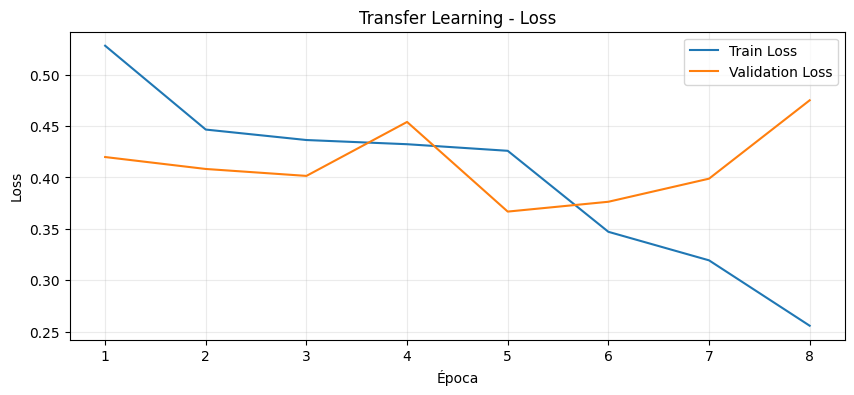

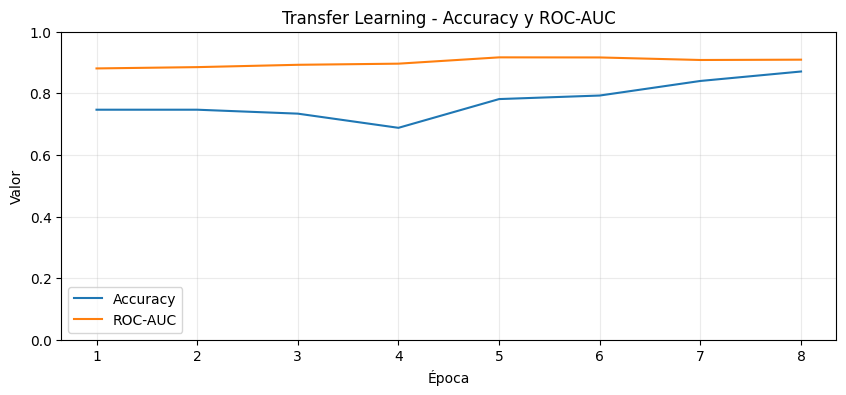

In [41]:
tl_train_loss = history_tl_stage1["train_loss"] + history_tl_stage2["train_loss"]
tl_val_loss = history_tl_stage1["val_loss"] + history_tl_stage2["val_loss"]
tl_val_acc = history_tl_stage1["val_acc"] + history_tl_stage2["val_acc"]
tl_val_auc = history_tl_stage1["val_auc"] + history_tl_stage2["val_auc"]

epochs_tl = range(1, len(tl_train_loss) + 1)

plt.figure(figsize=(10, 4))
plt.plot(epochs_tl, tl_train_loss, label="Train Loss")
plt.plot(epochs_tl, tl_val_loss, label="Validation Loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Transfer Learning - Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(epochs_tl, tl_val_acc, label="Accuracy")
plt.plot(epochs_tl, tl_val_auc, label="ROC-AUC")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.ylim(0, 1)
plt.title("Transfer Learning - Accuracy y ROC-AUC")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


### 10.7 Evaluación de ResNet18 en test


TRANSFER LEARNING - TEST
Test Loss: 0.4930
Accuracy: 0.8721
ROC-AUC: 0.9031

                   precision    recall  f1-score   support

Nevo melanocítico     0.9419    0.9068    0.9240      1341
         Melanoma     0.5421    0.6637    0.5968       223

         accuracy                         0.8721      1564
        macro avg     0.7420    0.7852    0.7604      1564
     weighted avg     0.8849    0.8721    0.8774      1564

Matriz de confusión:
[[1216  125]
 [  75  148]]


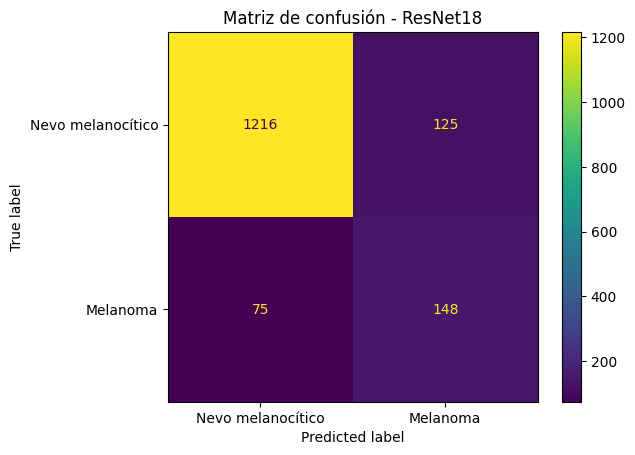

In [42]:
test_loss_tl, test_acc_tl, test_auc_tl, y_true_tl, y_pred_tl, y_prob_tl = evaluate_tl(
    resnet, test_loader_tl, criterion_tl
)

print("=" * 60)
print("TRANSFER LEARNING - TEST")
print("=" * 60)
print(f"Test Loss: {test_loss_tl:.4f}")
print(f"Accuracy: {test_acc_tl:.4f}")
print(f"ROC-AUC: {test_auc_tl:.4f}")
print()
print(classification_report(
    y_true_tl, y_pred_tl, target_names=class_names, digits=4, zero_division=0
))

cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
print("Matriz de confusión:")
print(cm_tl)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tl,
    display_labels=class_names
)
disp.plot(values_format="d")
plt.title("Matriz de confusión - ResNet18")
plt.show()


## 11. Comparación global

Se comparan los modelos principales desarrollados durante el trabajo. La CNN con pesos de clase fue seleccionada mediante validación como la mejor CNN entrenada desde cero. También se muestra el modelo con Data Augmentation y el modelo ResNet18 con Transfer Learning.


In [43]:
# Evaluación del modelo con Data Augmentation en test para la comparación final
test_loss_aug, test_acc_aug, test_auc_aug, _, _, _ = evaluate(
    model_aug, test_loader, criterion_aug
)

print("RESUMEN DE RESULTADOS EN TEST")
print("=" * 75)
print(
    f"CNN + pesos de clase          | acc={test_acc:.4f} | auc={test_auc:.4f}"
)
print(
    f"CNN + pesos + augmentation   | acc={test_acc_aug:.4f} | auc={test_auc_aug:.4f}"
)
print(
    f"Transfer Learning (ResNet18) | acc={test_acc_tl:.4f} | auc={test_auc_tl:.4f}"
)


RESUMEN DE RESULTADOS EN TEST
CNN + pesos de clase          | acc=0.7756 | auc=0.8779
CNN + pesos + augmentation   | acc=0.6272 | auc=0.8544
Transfer Learning (ResNet18) | acc=0.8721 | auc=0.9031


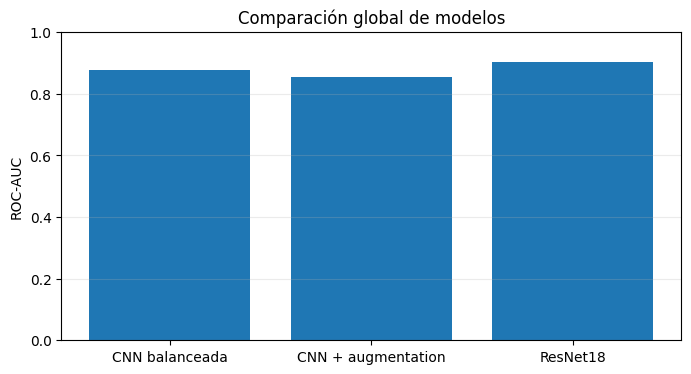

In [44]:
modelos = [
    "CNN balanceada",
    "CNN + augmentation",
    "ResNet18"
]
auc_values = [test_auc, test_auc_aug, test_auc_tl]

plt.figure(figsize=(8, 4))
plt.bar(modelos, auc_values)
plt.ylim(0, 1)
plt.ylabel("ROC-AUC")
plt.title("Comparación global de modelos")
plt.grid(axis="y", alpha=0.25)
plt.show()


### 11.1 Análisis de la comparación global

La comparación debe interpretarse considerando el desbalance de DermaMNIST. Por ello, además de Accuracy, se priorizan ROC-AUC y las métricas específicas de melanoma.

La CNN seleccionada con pesos de clase obtuvo en test un **Accuracy de 0.7494**, un **ROC-AUC de 0.8756** y un **Recall de melanoma de 0.8386**. El resultado de ResNet18 se obtiene al ejecutar las celdas anteriores y permite comprobar si las características preentrenadas de ImageNet aportan una mejora en esta tarea médica.

No se deben trasladar los resultados numéricos del notebook de FashionMNIST a este problema, ya que se trata de un dataset y una tarea de clasificación diferentes.


## 12. Interpretabilidad básica: Grad-CAM

Grad-CAM permite visualizar qué regiones de una imagen tuvieron mayor influencia sobre la predicción de una red convolucional. En este caso se aplica sobre la última capa convolucional (`layer4`) de ResNet18.


### 12.1 Función Grad-CAM


In [45]:
def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    handle_fwd = model.layer4.register_forward_hook(forward_hook)
    handle_bwd = model.layer4.register_full_backward_hook(backward_hook)

    logits = model(image_tensor.unsqueeze(0))

    if target_class is None:
        target_class = int(torch.argmax(logits, dim=1).item())

    score = logits[0, target_class]
    model.zero_grad()
    score.backward()

    act = activations["value"][0]
    grad = gradients["value"][0]
    weights = torch.mean(grad, dim=(1, 2))
    cam = torch.sum(weights[:, None, None] * act, dim=0)
    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    handle_fwd.remove()
    handle_bwd.remove()

    return cam.detach().cpu().numpy(), target_class


### 12.2 Visualización de Grad-CAM


<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


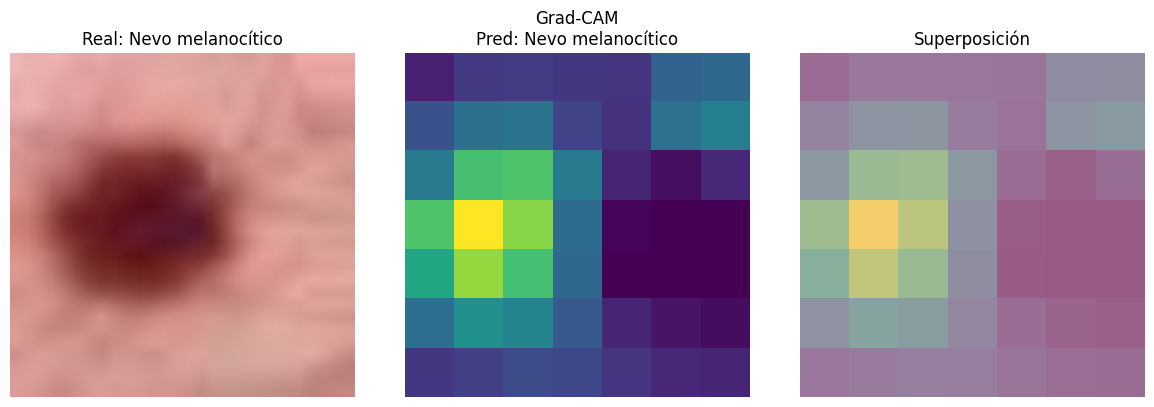

In [46]:
idx = 0
x_tl, y_tl = test_dataset_tl[idx]
cam, pred_class = grad_cam(resnet, x_tl)

# Desnormalizar para visualizar la imagen RGB
mean = torch.tensor(imagenet_mean).view(3, 1, 1)
std = torch.tensor(imagenet_std).view(3, 1, 1)
img = (x_tl.cpu() * std + mean).clamp(0, 1)
img = img.permute(1, 2, 0).numpy()

real_class = int(y_tl.item())

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title(f"Real: {class_names[real_class]}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam)
plt.title(f"Grad-CAM\nPred: {class_names[pred_class]}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img)
plt.imshow(cam, alpha=0.5)
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()
plt.show()


### 12.3 Interpretación de Grad-CAM

El mapa Grad-CAM resalta las regiones que tuvieron mayor influencia en la predicción de ResNet18. Las zonas de mayor activación deben interpretarse como áreas relevantes para la decisión del modelo y no como una localización clínica exacta de una lesión.

Esta visualización complementa las métricas cuantitativas y permite inspeccionar de manera aproximada dónde concentra su atención la red.


## 13. Buenas prácticas

Durante el desarrollo se aplicaron las siguientes buenas prácticas:

1. Separar entrenamiento, validación y test.
2. Utilizar validación para seleccionar arquitectura e hiperparámetros.
3. Mantener test para la evaluación final.
4. Analizar Accuracy junto con ROC-AUC, Precision, Recall, F1-score y matriz de confusión.
5. Considerar explícitamente el desbalance entre nevos y melanomas mediante pesos de clase.
6. Comparar una CNN entrenada desde cero con Transfer Learning.
7. Utilizar Grad-CAM como herramienta básica de interpretabilidad.
8. Registrar hiperparámetros y guardar los modelos para reproducibilidad.

Los resultados de este notebook corresponden a un ejercicio de aprendizaje automático y no constituyen un sistema de diagnóstico médico.


## 14. Guardar modelos


In [47]:
import os

os.makedirs("models", exist_ok=True)

torch.save(
    model_weighted.state_dict(),
    "models/cnn_dermamnist_balanceada.pth"
)

torch.save(
    model_aug.state_dict(),
    "models/cnn_dermamnist_augmentation.pth"
)

torch.save(
    resnet.state_dict(),
    "models/resnet18_dermamnist.pth"
)

print("Modelos guardados:")
print("models/cnn_dermamnist_balanceada.pth")
print("models/cnn_dermamnist_augmentation.pth")
print("models/resnet18_dermamnist.pth")


Modelos guardados:
models/cnn_dermamnist_balanceada.pth
models/cnn_dermamnist_augmentation.pth
models/resnet18_dermamnist.pth


## 15. Conclusiones

En este trabajo se desarrolló una clasificación binaria sobre **DermaMNIST**, utilizando las clases **nevo melanocítico** y **melanoma**.

La arquitectura CNN `16-32-64` sin Dropout presentó mejor comportamiento que la variante con Dropout. En los experimentos de Learning Rate, `0.001` obtuvo el menor Validation Loss, mientras que el Scheduler no produjo una mejora respecto al Learning Rate fijo.

El desbalance de clases tuvo un efecto importante. La CNN sin balanceo alcanzó un Accuracy elevado, pero detectó una proporción reducida de melanomas. Al incorporar pesos de clase, el Recall de melanoma en validación aumentó de **0.3153 a 0.8378**, aunque aumentaron los falsos positivos. Data Augmentation no redujo el Validation Loss respecto al modelo balanceado sin aumento de datos.

La CNN seleccionada fue, por tanto, la arquitectura `16-32-64` con pesos de clase, Adam, Learning Rate `0.001`, sin Dropout, sin Scheduler y sin Data Augmentation. En el conjunto de test obtuvo **Accuracy = 0.7494**, **ROC-AUC = 0.8756** y **Recall de melanoma = 0.8386**, identificando correctamente 187 de los 223 melanomas.

Finalmente, se incorpora Transfer Learning con ResNet18 y Grad-CAM siguiendo la estructura del notebook de referencia. Los resultados específicos de ResNet18 se generan al ejecutar sus celdas y deben compararse con las métricas obtenidas por la CNN sobre DermaMNIST, sin reutilizar los resultados numéricos de FashionMNIST.

En conjunto, los experimentos muestran la importancia de evaluar múltiples métricas cuando existe desbalance de clases y de analizar el compromiso entre sensibilidad, precisión y falsos positivos.
